# Testing Sparsity

Our esm embeddings seem to be highly correlated. The popDMS framework is having trouble picking out the real selection coefficients for values under almost any fitness regime

## InterPLM

a paper from stanford using a SAE on top of the PLM embeddings. the SAE was shown to find distinct biological features from the superposition of embedding values from the protein sequences. Can running popDMS on these abstracted features provide better results than simply running them on the highly-correlated emnbedding space? 

In [1]:
test = 1

## PCA's

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import sys

esmDMS_DIR = "/Users/dylanwells/popDMS/esmDMS"

sys.path.insert(0, esmDMS_DIR)
from esmdmsfunctions import (
    get_eigenvector_simulation_results,
    generate_selection, gaussian_selection, zero_selection,
    z_normalize, load_final_df,
)
from scipy.stats import pearsonr

### Configuration — set paths and run parameters here

In [4]:
import os

# ── Paths to analyse (name → directory containing layer0/, layer1/, … subdirs)
comb_path = esmDMS_DIR + "/data/bg_bf_comb_data"
bg_path   = esmDMS_DIR + "/data/inference_data/BG505"
bf_path   = esmDMS_DIR + "/data/inference_results"

PATHS = {
    "comb":  comb_path,
    "BG505": bg_path,
    "BF520": bf_path,
}

# ── Layers to analyze
LAYERS = [12]

# ── Simulation parameters
N_GENS      = 30      # number of generations to simulate
SAVE_EVERY  = 1       # save counts every N generations
FITNESS_FN  = 'exp'   # 'plus1' or 'exp'

# ── Eigenvector / PCA parameters
VARIANCE_EXPLAINED_CUTOFF = 0.95   # keep PCs that together explain this fraction of variance
WEIGHT_BY_INITIAL_FREQ    = False  # weight covariance matrix by pre-selection counts

# ── Selection function (generate_selection, gaussian_selection, or zero_selection)
SEL_FUNC = generate_selection

# ── Inference flags
RUN_INFERENCE    = True
RUN_GAMMA        = False
CALC_ERROR_BARS  = False
INFER_IGNORED    = True

### Run eigenvector simulation

In [9]:
all_results = {}   # path_name -> (all_layer_fits, all_sel_coeffs, detailed_results, gamma_results, all_gen_counts, eig_info)

for path_name, path in PATHS.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {path_name}  |  {path}")
    print('='*60)

    results = get_eigenvector_simulation_results(
        n_gens=N_GENS,
        embedding_df_path=path,
        sel_func=SEL_FUNC,
        inference=RUN_INFERENCE,
        gamma_analysis=RUN_GAMMA,
        fitness=FITNESS_FN,
        save_every=SAVE_EVERY,
        layers=LAYERS,
        variance_explained_cutoff=VARIANCE_EXPLAINED_CUTOFF,
        weight_by_initial_freq=WEIGHT_BY_INITIAL_FREQ,
        calc_error_bars=CALC_ERROR_BARS,
        infer_ignored_dims=INFER_IGNORED,
    )
    all_results[path_name] = results

print("\nDone. Datasets completed:", list(all_results.keys()))


Dataset: comb  |  /Users/dylanwells/CodingProjects/popDMS/esmDMS/data/bg_bf_comb_data
Running layer 12...
  Layer 12: keeping 54/640 eigenvectors (95.1% variance explained)
  Running simulation...
  Running inference for layer 12...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data...

Dataset: BG505  |  /Users/dylanwells/CodingProjects/popDMS/esmDMS/data/inference_data/BG505
Running layer 12...
  Layer 12: keeping 106/640 eigenvectors (95.0% variance explained)
  Running simulation...
  Running inference for layer 12...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data...

Dataset: BF520  |  /Users/dylanwells/CodingProjects/popDMS/esmDMS/data/inference_results
Running layer 12...
  Layer 12: keeping 103/640 eigenvectors (95.0% variance explained)
  Running simulation...
  Running inference for layer 12...
Transferring simulation data to inference dataframe format.

### Scree plot — variance explained by each eigenvector

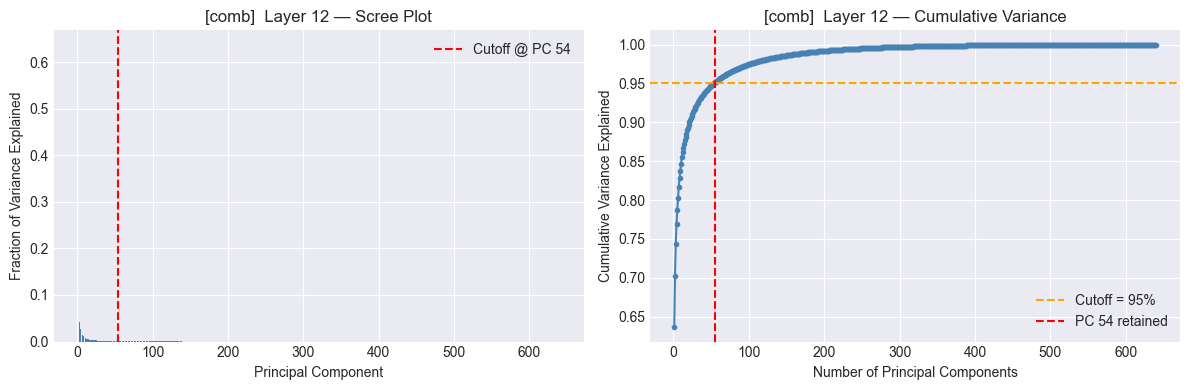

[comb]  Layer 12: 54 PCs retained, 95.1% variance explained


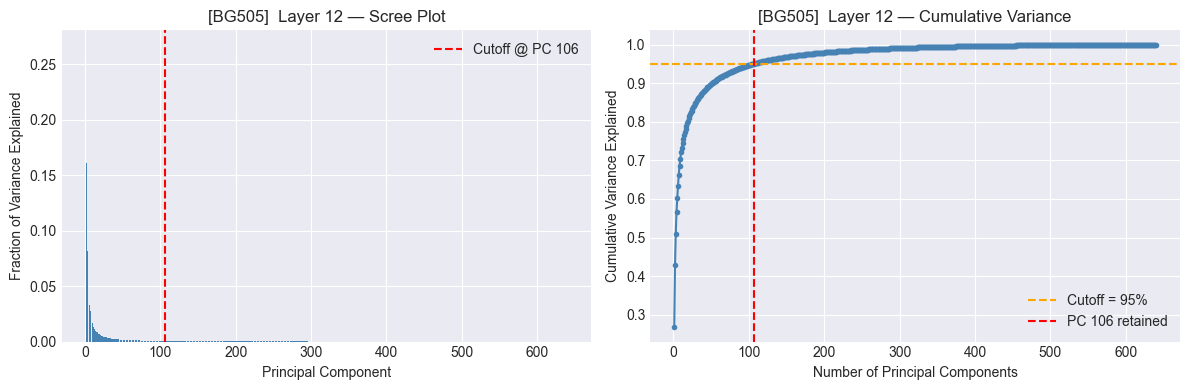

[BG505]  Layer 12: 106 PCs retained, 95.0% variance explained


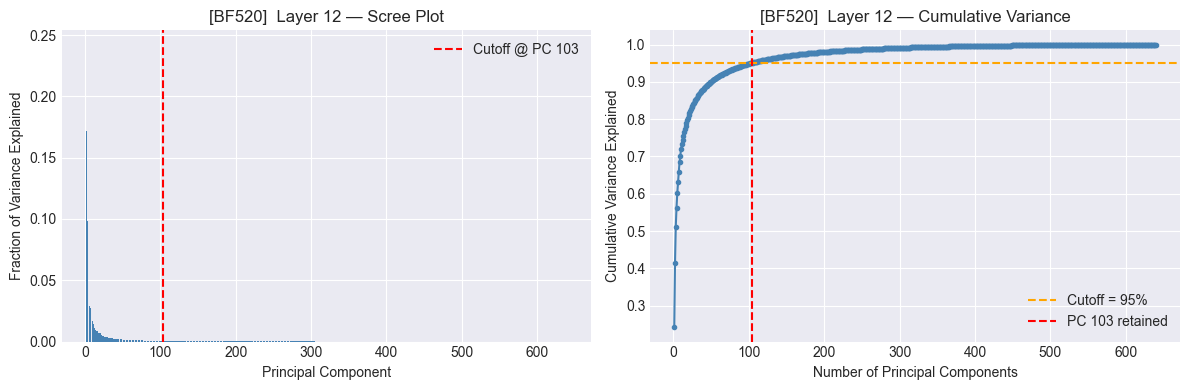

[BF520]  Layer 12: 103 PCs retained, 95.0% variance explained


In [10]:
plt.style.use('seaborn-v0_8-darkgrid')

for path_name, results in all_results.items():
    all_layer_fits, all_sel_coeffs, detailed_results, gamma_results, all_gen_counts, eig_info = results

    for layer in LAYERS:
        info = eig_info[layer]
        eigenvalues = np.maximum(info['eigenvalues'], 0.0)
        cum_var = np.cumsum(eigenvalues) / eigenvalues.sum()
        n_keep = info['n_components']

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].bar(range(1, len(eigenvalues) + 1), eigenvalues / eigenvalues.sum(), color='steelblue')
        axes[0].axvline(n_keep + 0.5, color='red', linestyle='--', label=f'Cutoff @ PC {n_keep}')
        axes[0].set_xlabel('Principal Component')
        axes[0].set_ylabel('Fraction of Variance Explained')
        axes[0].set_title(f'[{path_name}]  Layer {layer} — Scree Plot')
        axes[0].legend()

        axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker='o', markersize=3, color='steelblue')
        axes[1].axhline(VARIANCE_EXPLAINED_CUTOFF, color='orange', linestyle='--',
                        label=f'Cutoff = {VARIANCE_EXPLAINED_CUTOFF:.0%}')
        axes[1].axvline(n_keep + 0.5, color='red', linestyle='--', label=f'PC {n_keep} retained')
        axes[1].set_xlabel('Number of Principal Components')
        axes[1].set_ylabel('Cumulative Variance Explained')
        axes[1].set_title(f'[{path_name}]  Layer {layer} — Cumulative Variance')
        axes[1].legend()

        plt.tight_layout()
        plt.show()
        print(f"[{path_name}]  Layer {layer}: {n_keep} PCs retained, "
              f"{info['variance_explained']*100:.1f}% variance explained")

### True vs inferred selection coefficients (in eigenvector space)

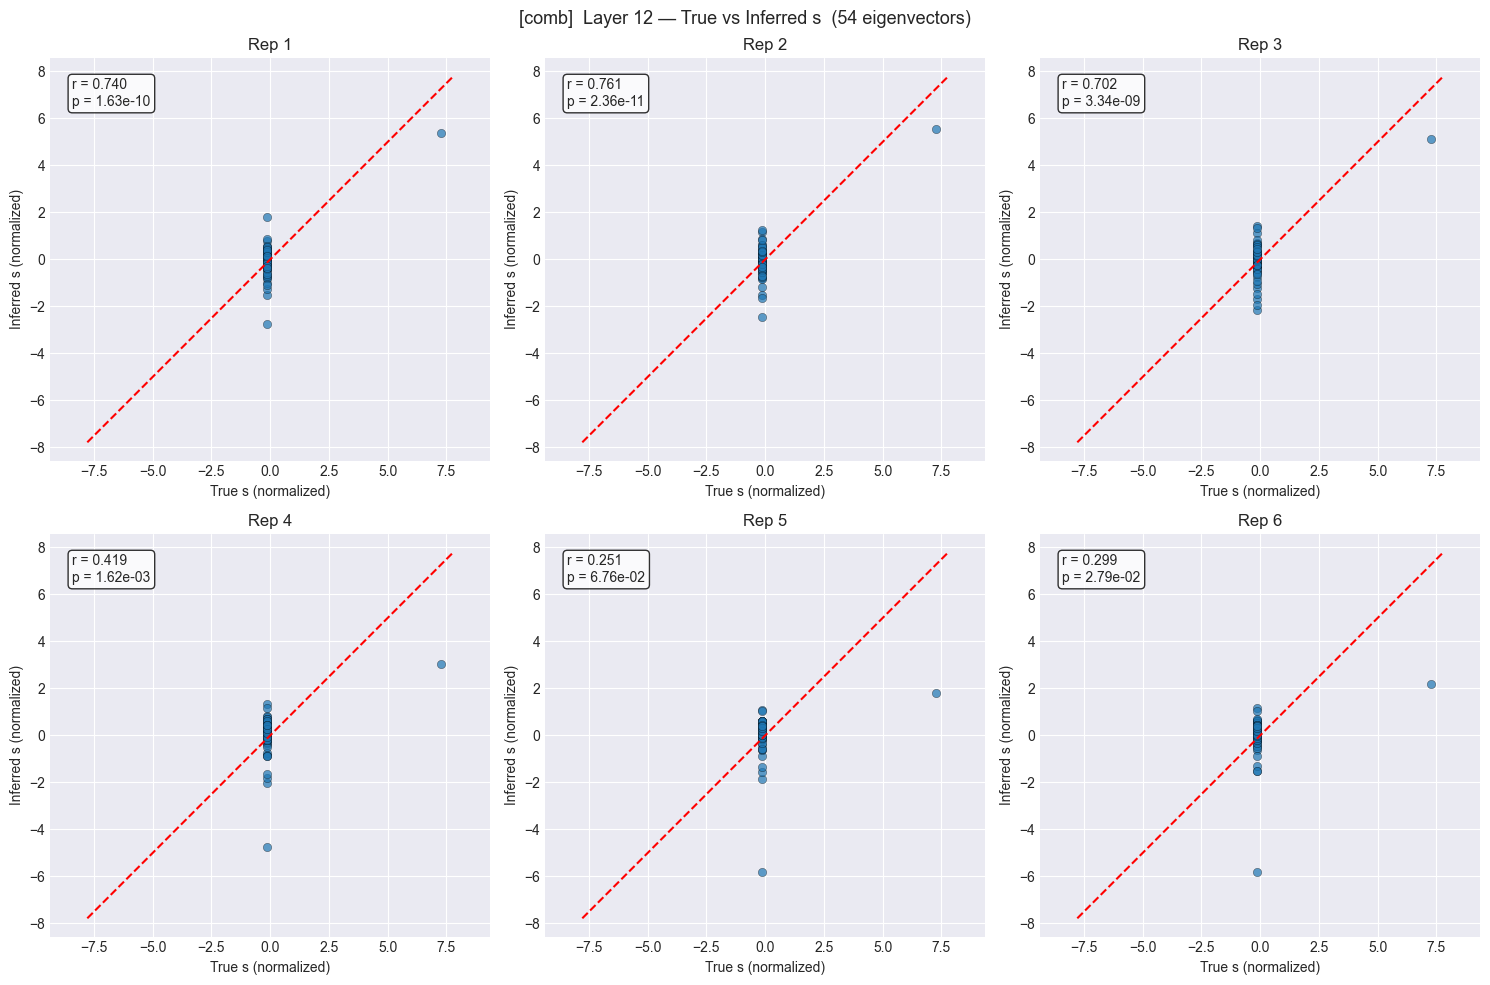

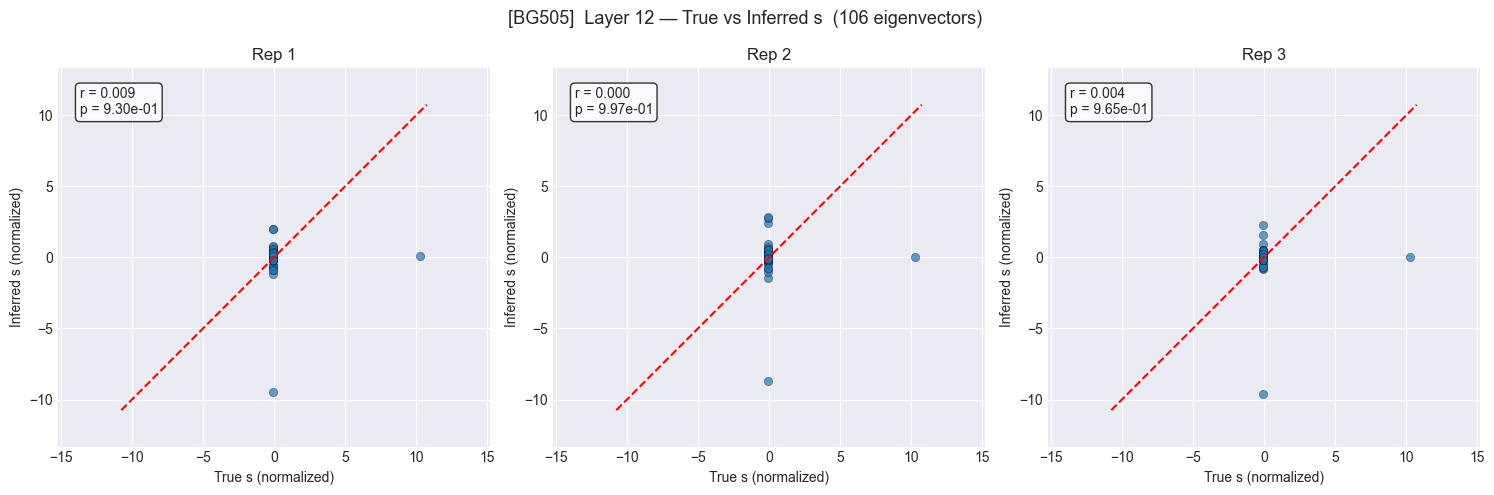

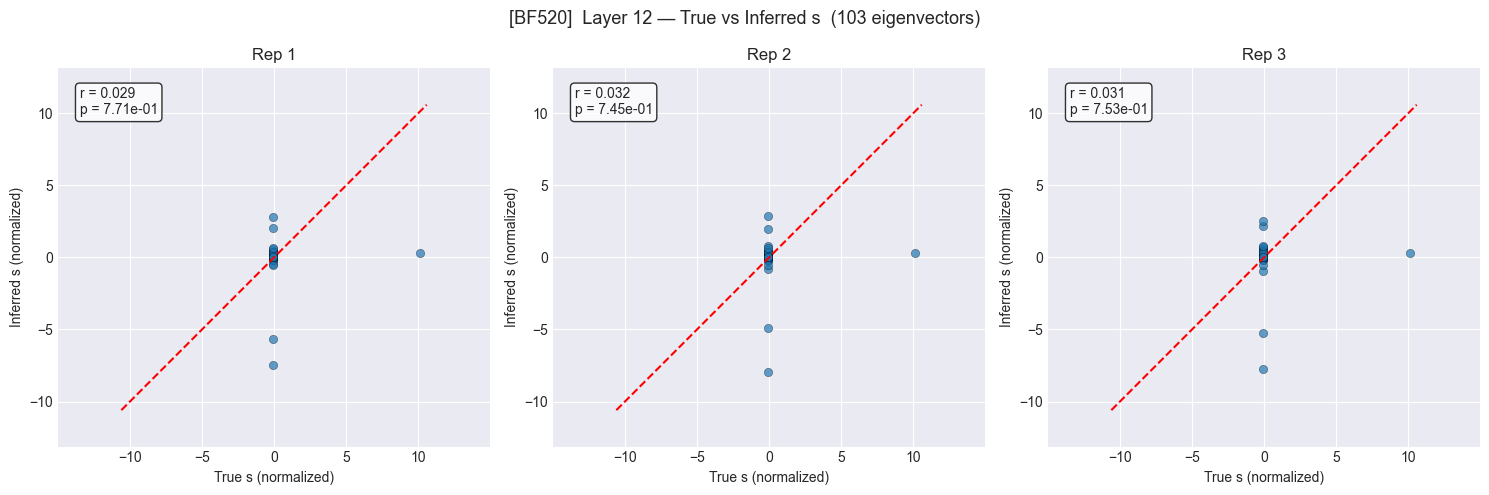

In [11]:
MAX_COLS = 3

for path_name, results in all_results.items():
    all_layer_fits, all_sel_coeffs, detailed_results, gamma_results, all_gen_counts, eig_info = results

    for layer in LAYERS:
        if layer not in detailed_results:
            print(f"[{path_name}]  Layer {layer}: no inference results (run with inference=True)")
            continue

        true_s       = all_sel_coeffs[layer]
        s_reps       = detailed_results[layer][0]
        n_reps       = len(s_reps)
        n_components = eig_info[layer]['n_components']

        n_cols = min(n_reps, MAX_COLS)
        n_rows = int(np.ceil(n_reps / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)

        for rep in range(n_reps):
            row, col = divmod(rep, n_cols)
            ax = axes[row][col]

            true_norm     = z_normalize(true_s)
            inferred_norm = z_normalize(s_reps[rep])

            ax.scatter(true_norm, inferred_norm, alpha=0.7, edgecolors='k', linewidths=0.3)
            lim = max(np.abs(true_norm).max(), np.abs(inferred_norm).max()) + 0.5
            ax.plot([-lim, lim], [-lim, lim], 'r--')
            ax.set_xlabel('True s (normalized)')
            ax.set_ylabel('Inferred s (normalized)')
            ax.set_title(f'Rep {rep + 1}')
            ax.axis('equal')

            corr, pval = pearsonr(true_norm, inferred_norm)
            ax.annotate(f'r = {corr:.3f}\np = {pval:.2e}',
                        xy=(0.05, 0.95), xycoords='axes fraction',
                        ha='left', va='top', fontsize=10,
                        bbox=dict(boxstyle='round', fc='white', alpha=0.8))

        for idx in range(n_reps, n_rows * n_cols):
            row, col = divmod(idx, n_cols)
            axes[row][col].set_visible(False)

        fig.suptitle(f'[{path_name}]  Layer {layer} — True vs Inferred s  ({n_components} eigenvectors)', fontsize=13)
        plt.tight_layout()
        plt.show()

### Cross-replicate consistency of inferred s

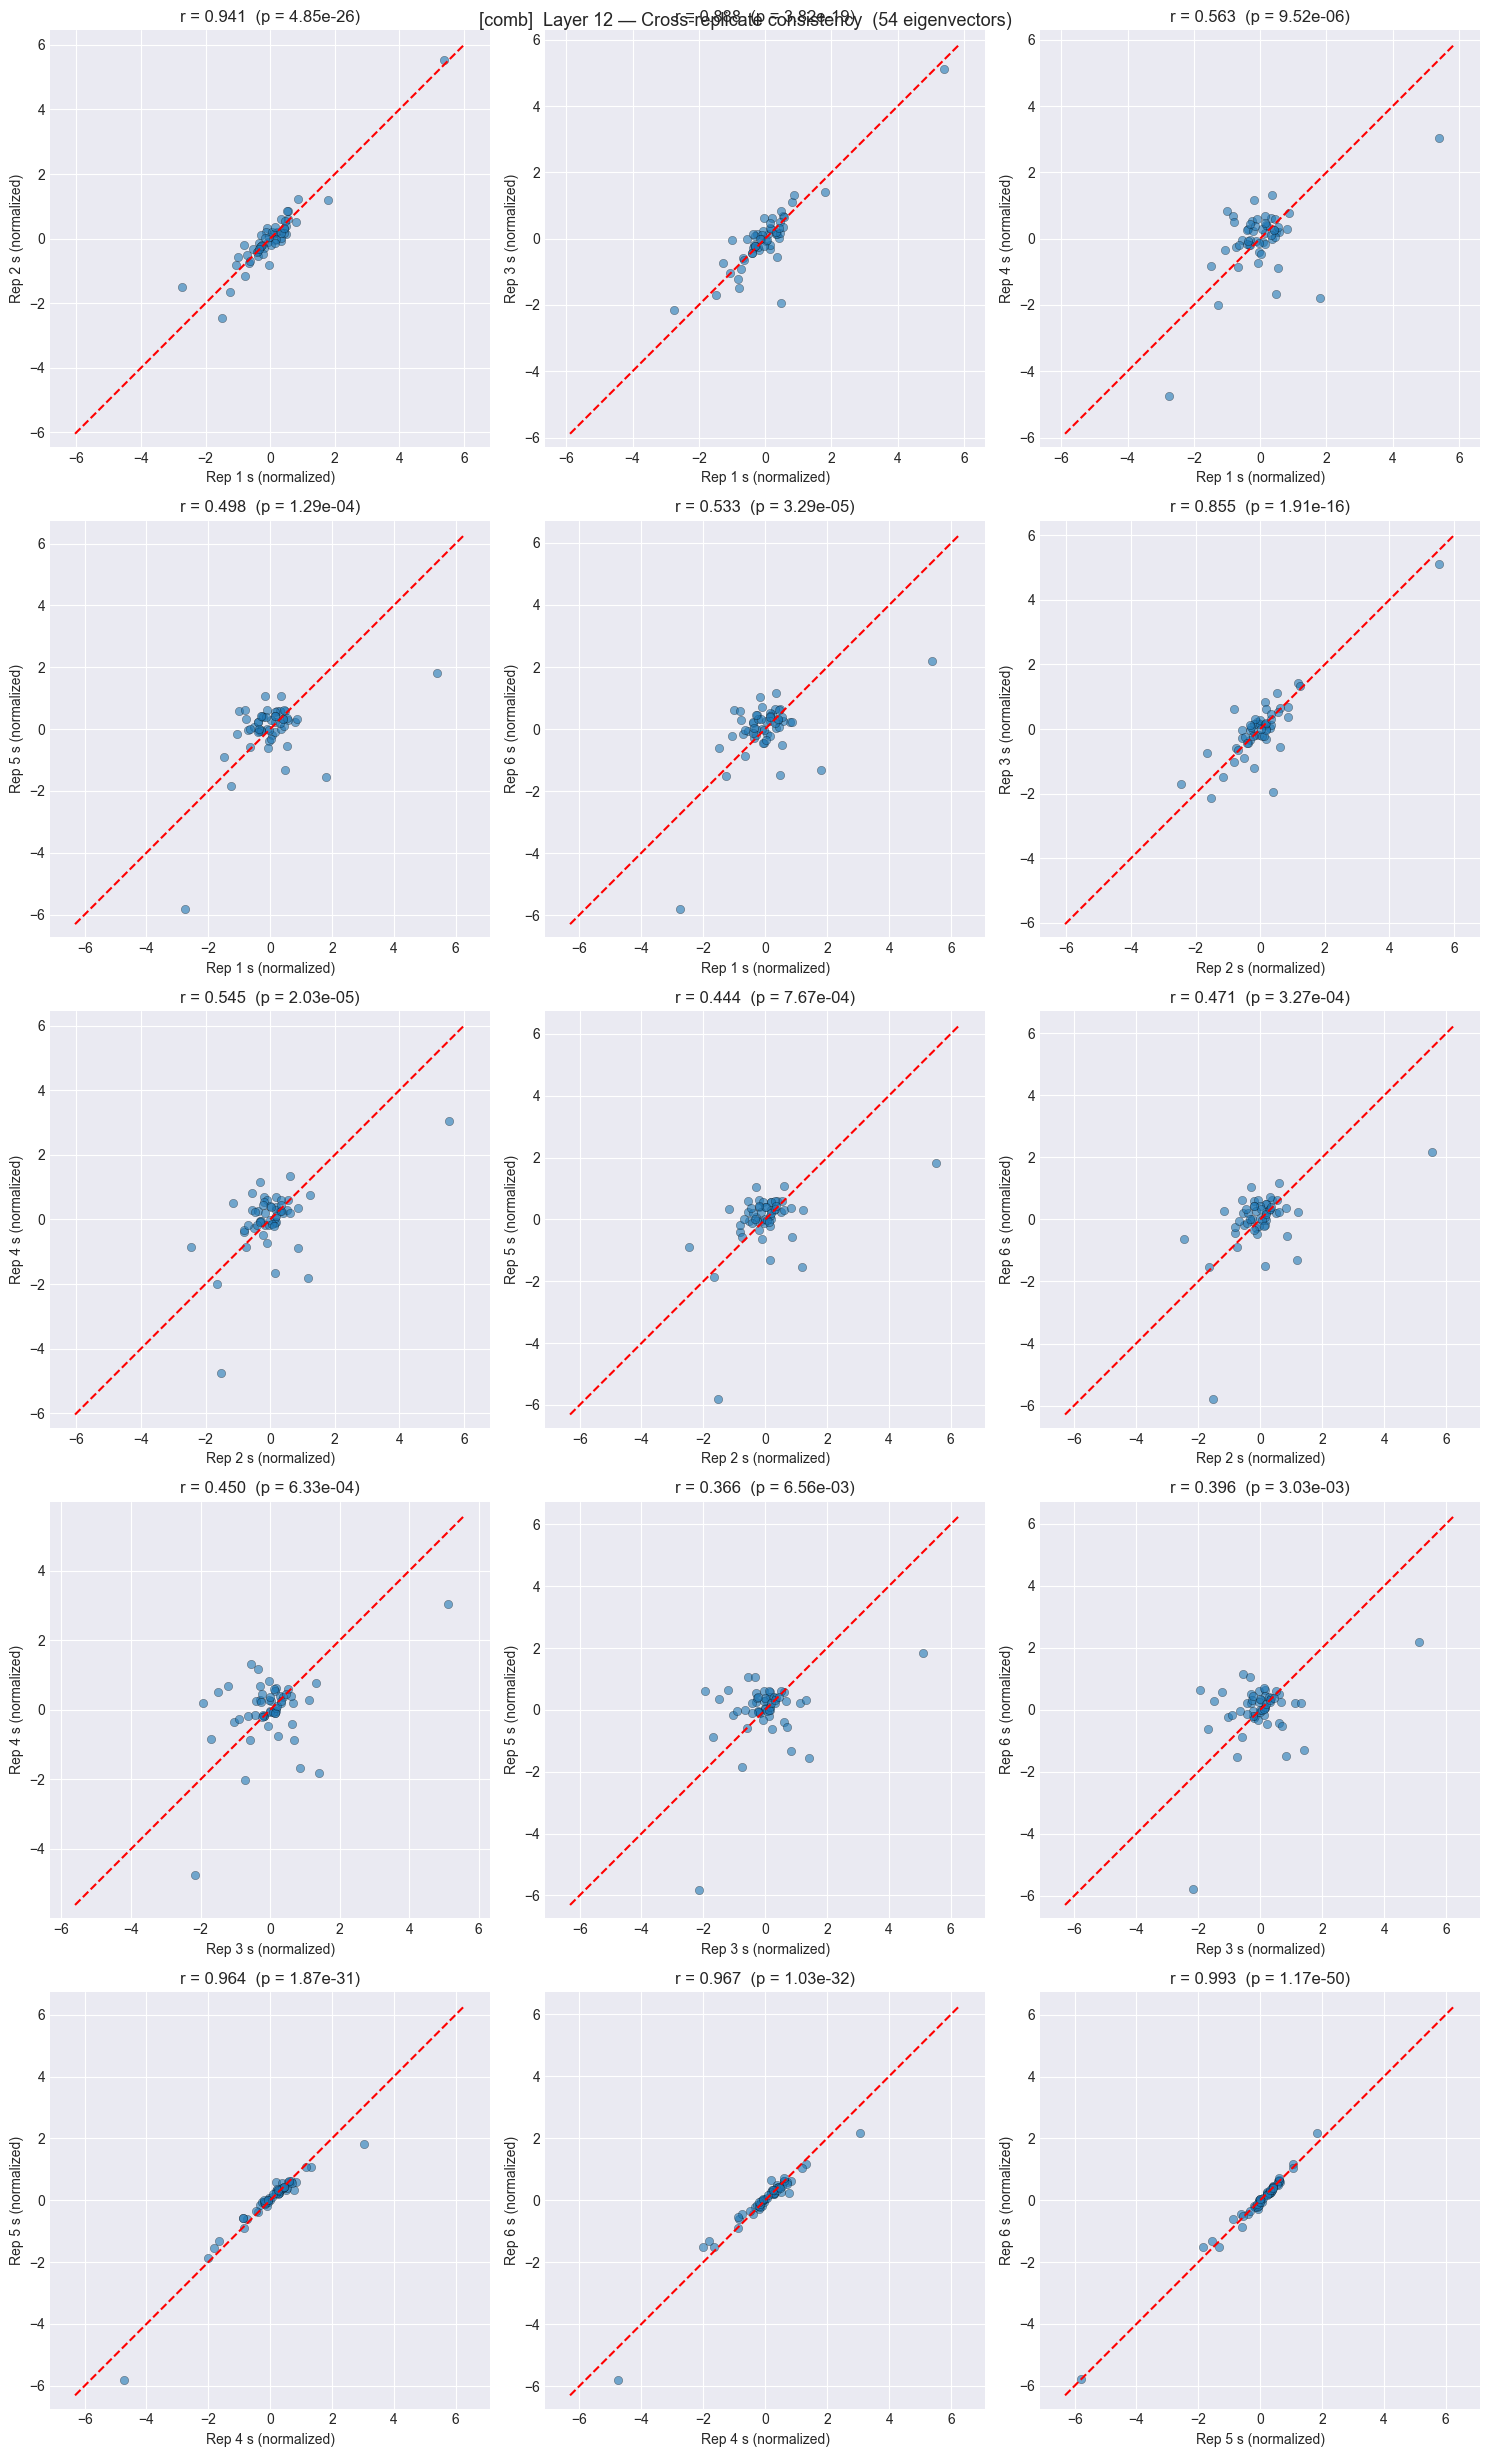

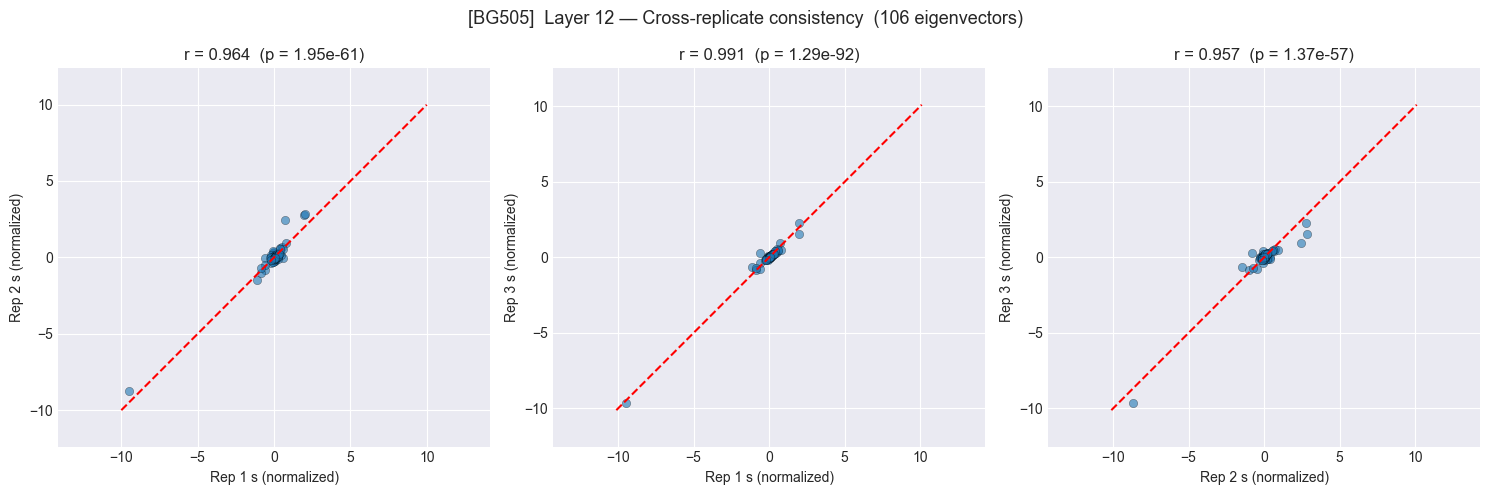

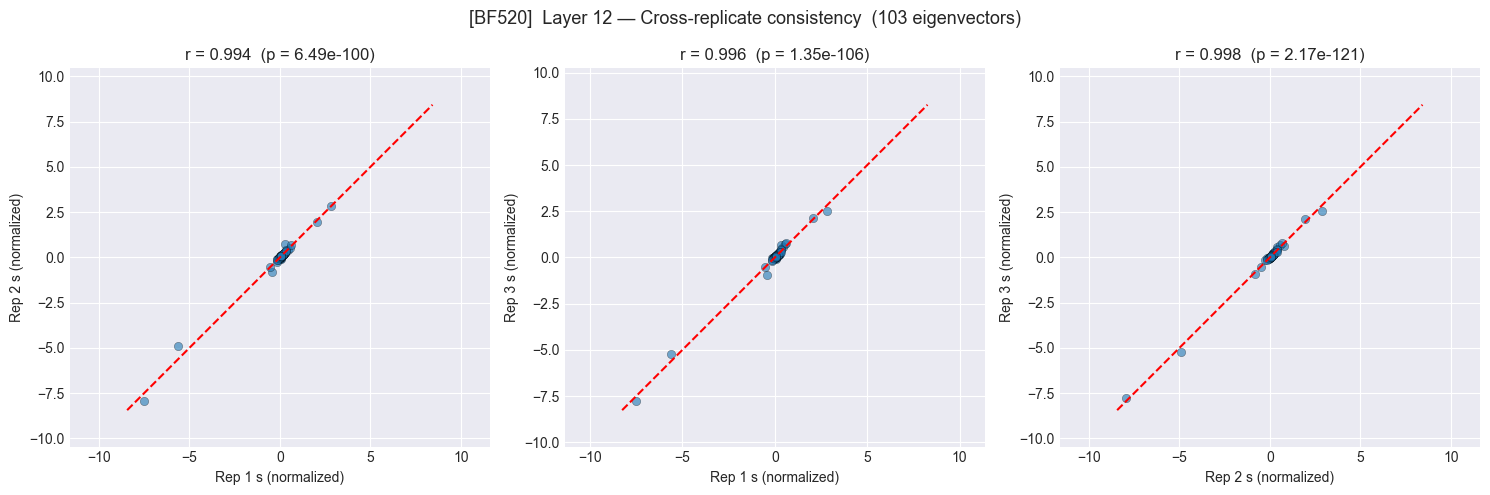

In [12]:
MAX_COLS = 3

for path_name, results in all_results.items():
    all_layer_fits, all_sel_coeffs, detailed_results, gamma_results, all_gen_counts, eig_info = results

    for layer in LAYERS:
        if layer not in detailed_results:
            print(f"[{path_name}]  Layer {layer}: no inference results")
            continue

        s_reps     = detailed_results[layer][0]
        n_reps     = len(s_reps)
        rep_pairs  = [(i, j) for i in range(n_reps) for j in range(i + 1, n_reps)]
        n_plots    = len(rep_pairs)

        n_cols = min(n_plots, MAX_COLS)
        n_rows = int(np.ceil(n_plots / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)

        for idx, (ri, rj) in enumerate(rep_pairs):
            row, col = divmod(idx, n_cols)
            ax = axes[row][col]

            si = z_normalize(s_reps[ri])
            sj = z_normalize(s_reps[rj])
            ax.scatter(si, sj, alpha=0.6, edgecolors='k', linewidths=0.3)
            lim = max(np.abs(si).max(), np.abs(sj).max()) + 0.5
            ax.plot([-lim, lim], [-lim, lim], 'r--')
            ax.set_xlabel(f'Rep {ri + 1} s (normalized)')
            ax.set_ylabel(f'Rep {rj + 1} s (normalized)')
            corr, pval = pearsonr(si, sj)
            ax.set_title(f'r = {corr:.3f}  (p = {pval:.2e})')
            ax.axis('equal')

        for idx in range(n_plots, n_rows * n_cols):
            row, col = divmod(idx, n_cols)
            axes[row][col].set_visible(False)

        fig.suptitle(f'[{path_name}]  Layer {layer} — Cross-replicate consistency  ({eig_info[layer]["n_components"]} eigenvectors)', fontsize=13)
        plt.tight_layout()
        plt.show()

## Individual Fitness: True vs Inferred

For each variant in the population we compare its **true** fitness (used during simulation) to the fitness implied by the **inferred** selection coefficients.

True fitness is computed as `f(e · s_true)` where `e` is the projected embedding and `s_true` is the ground-truth selection vector.  
Inferred fitness is `f(e · s_inferred)` using the posterior-mean `s` returned by popDMS inference.

Both are z-normalised before comparison so the scale difference between datasets does not dominate the plots.

In [13]:
from scipy.stats import spearmanr
from esmdmsfunctions import (
    load_final_df,
    calculate_fitness_exp,
    calculate_fitness_plus1,
)

def compute_individual_fitness(all_results, paths, layers, fitness_fn=FITNESS_FN):
    """
    For each (dataset, layer, replicate) compute per-individual true and inferred fitness.

    Returns
    -------
    fitness_data : dict
        {path_name: {layer: {'true': array(N,),
                              'inferred': array(N, n_reps),
                              'n_reps': int}}}
    """
    calc_fit = calculate_fitness_exp if fitness_fn == 'exp' else calculate_fitness_plus1

    fitness_data = {}
    for path_name, results in all_results.items():
        all_layer_fits, _, detailed_results, _, _, eig_info = results
        fitness_data[path_name] = {}

        for layer in layers:
            if layer not in detailed_results:
                print(f"[{path_name}] layer {layer}: no inference results, skipping.")
                continue

            # Load raw embeddings and project into PCA space
            raw_df = load_final_df(layer, paths[path_name])
            embeddings = np.vstack(raw_df['Embedding'].tolist())          # (N, D)
            proj_mat   = eig_info[layer]['projection_matrix']             # (D, k)
            proj_emb   = embeddings @ proj_mat                            # (N, k)

            # True fitness (already computed during simulation)
            true_fits = np.array(all_layer_fits[layer], dtype=float)     # (N,)

            # Inferred fitness: one estimate per replicate
            s_reps     = detailed_results[layer][0]                      # list of n_reps arrays (k,)
            n_reps     = len(s_reps)
            inferred   = np.zeros((len(proj_emb), n_reps), dtype=float)
            for rep, s in enumerate(s_reps):
                for i, emb in enumerate(proj_emb):
                    inferred[i, rep] = calc_fit(emb, s)

            fitness_data[path_name][layer] = {
                'true':     true_fits,
                'inferred': inferred,
                'n_reps':   n_reps,
            }
            print(f"[{path_name}] layer {layer}: {len(true_fits)} variants, {n_reps} replicates")

    return fitness_data

fitness_data = compute_individual_fitness(all_results, PATHS, LAYERS, FITNESS_FN)


[comb] layer 12: 26552 variants, 6 replicates
[BG505] layer 12: 13380 variants, 3 replicates
[BF520] layer 12: 13172 variants, 3 replicates


### Scatter plots — true vs inferred fitness per individual

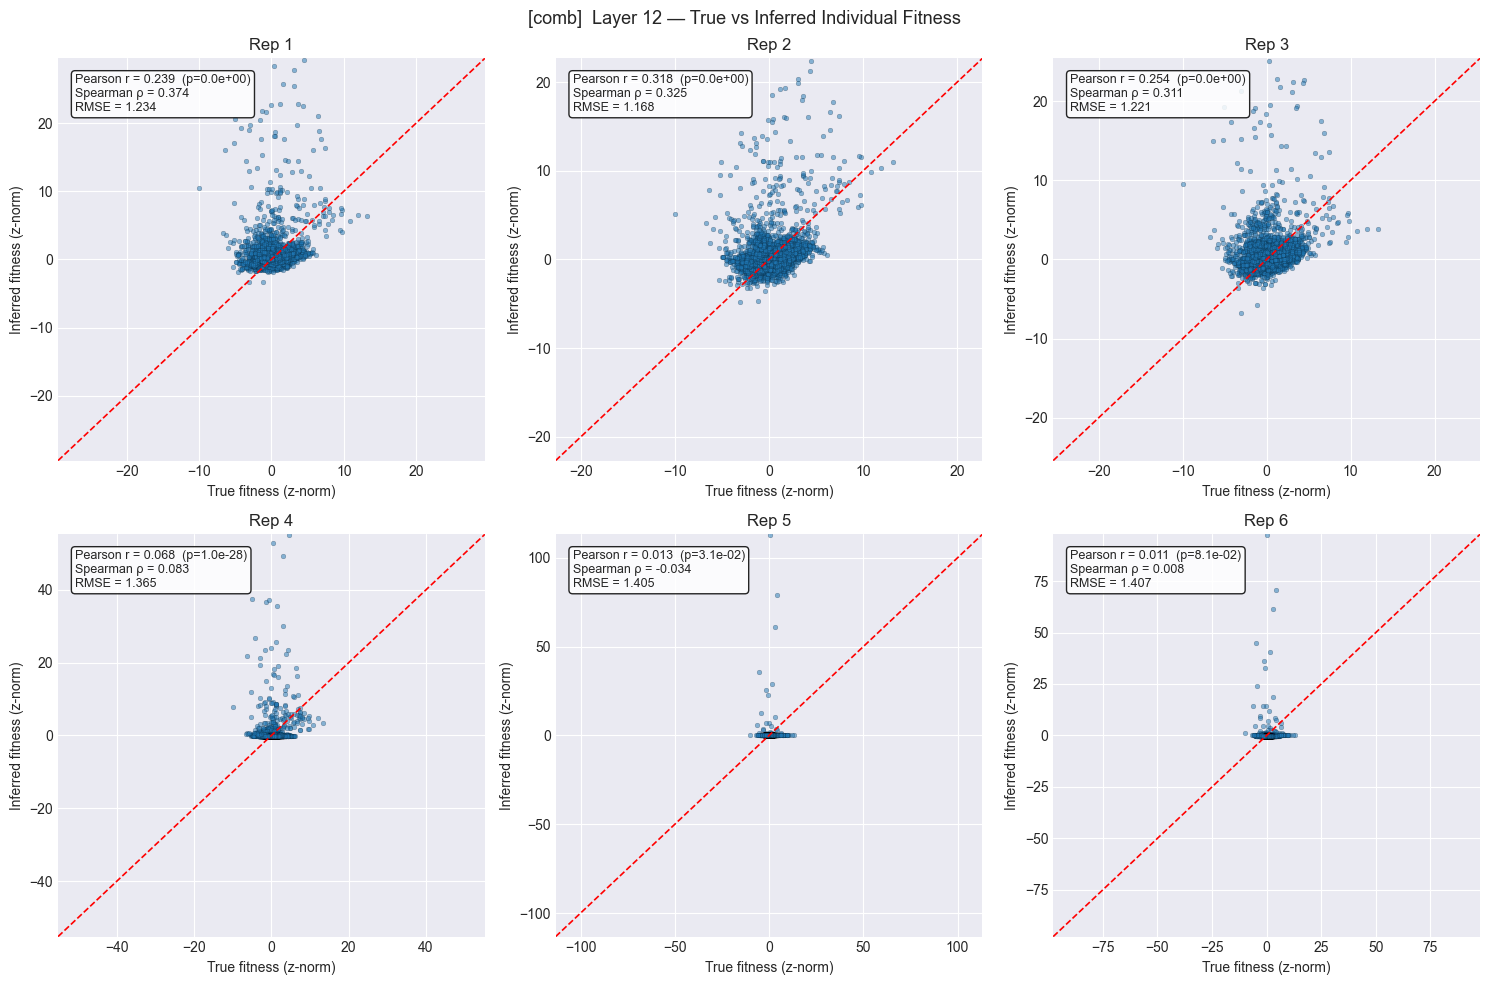

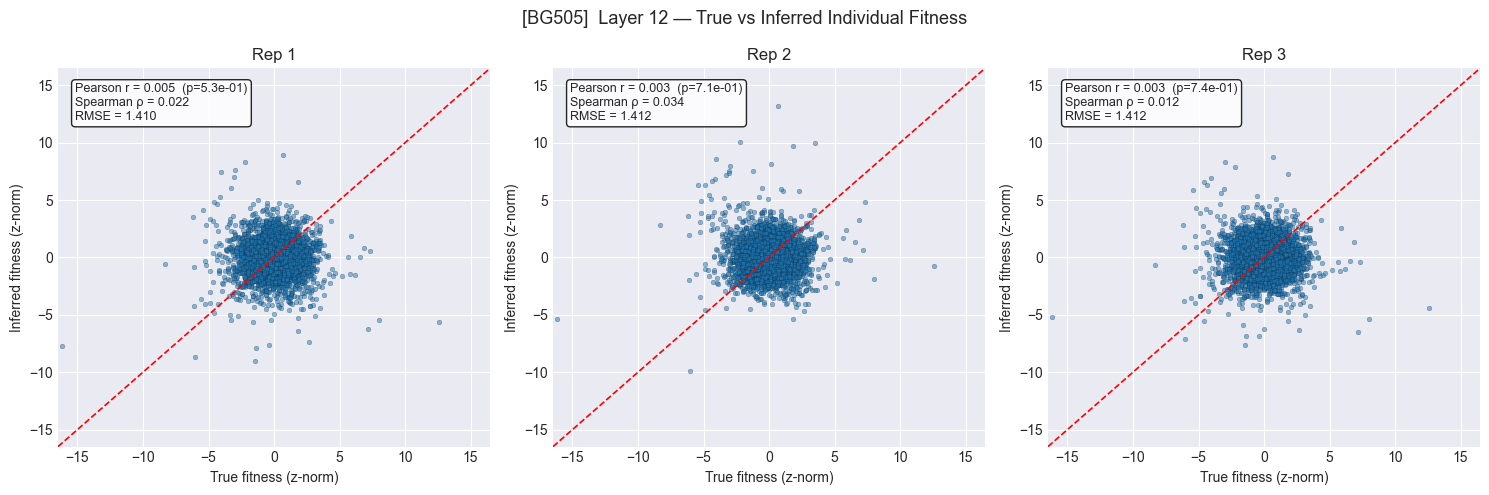

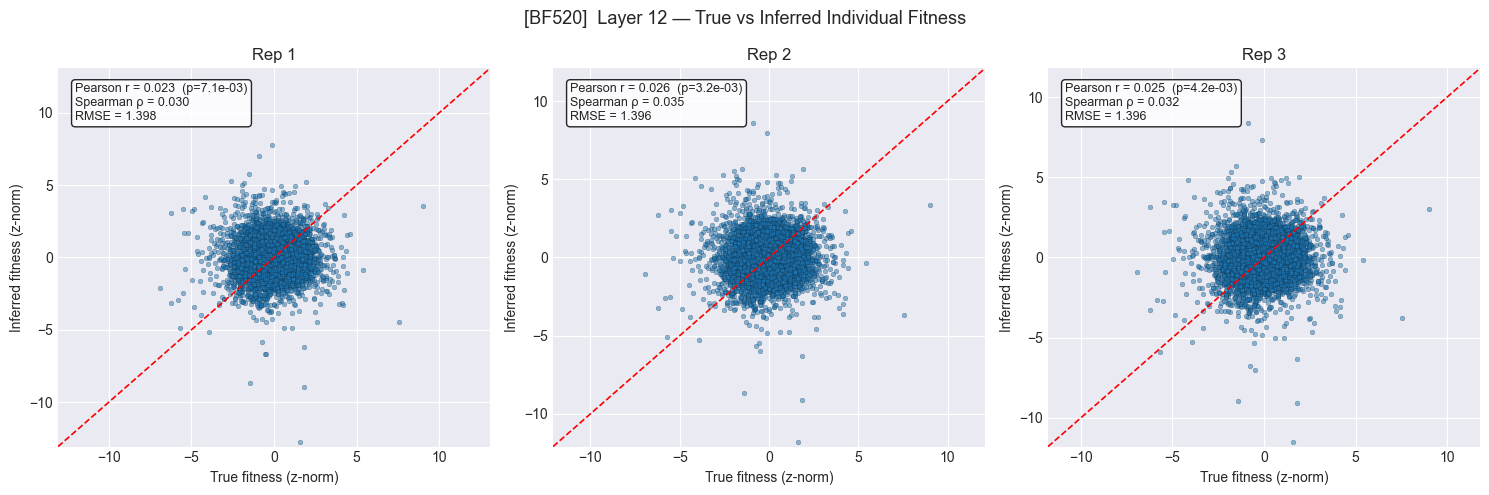

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
MAX_COLS = 3

for path_name, layer_dict in fitness_data.items():
    for layer, fd in layer_dict.items():
        true_norm = z_normalize(fd['true'])
        n_reps    = fd['n_reps']

        n_cols = min(n_reps, MAX_COLS)
        n_rows = int(np.ceil(n_reps / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(5 * n_cols, 5 * n_rows), squeeze=False)

        for rep in range(n_reps):
            row, col = divmod(rep, n_cols)
            ax = axes[row][col]

            inf_norm = z_normalize(fd['inferred'][:, rep])

            ax.scatter(true_norm, inf_norm, alpha=0.5, s=12,
                       edgecolors='k', linewidths=0.2)

            lim = max(np.abs(true_norm).max(), np.abs(inf_norm).max()) + 0.3
            ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.2, label='y = x')
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            ax.set_xlabel('True fitness (z-norm)')
            ax.set_ylabel('Inferred fitness (z-norm)')
            ax.set_title(f'Rep {rep + 1}')

            r, pval   = pearsonr(true_norm, inf_norm)
            rho, _    = spearmanr(true_norm, inf_norm)
            rmse      = np.sqrt(np.mean((true_norm - inf_norm) ** 2))
            ax.annotate(
                f'Pearson r = {r:.3f}  (p={pval:.1e})\nSpearman ρ = {rho:.3f}\nRMSE = {rmse:.3f}',
                xy=(0.04, 0.96), xycoords='axes fraction',
                ha='left', va='top', fontsize=9,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))

        # Hide unused subplots
        for idx in range(n_reps, n_rows * n_cols):
            axes[divmod(idx, n_cols)[0]][divmod(idx, n_cols)[1]].set_visible(False)

        fig.suptitle(
            f'[{path_name}]  Layer {layer} — True vs Inferred Individual Fitness',
            fontsize=13)
        plt.tight_layout()
        plt.show()


### Error distribution analysis

Residuals (`inferred − true`, both z-normalised) reveal whether errors are systematic (biased, skewed) or random (centred, Gaussian). We also inspect how error magnitude varies across the fitness range — are high-fitness variants harder to recover than low-fitness ones?

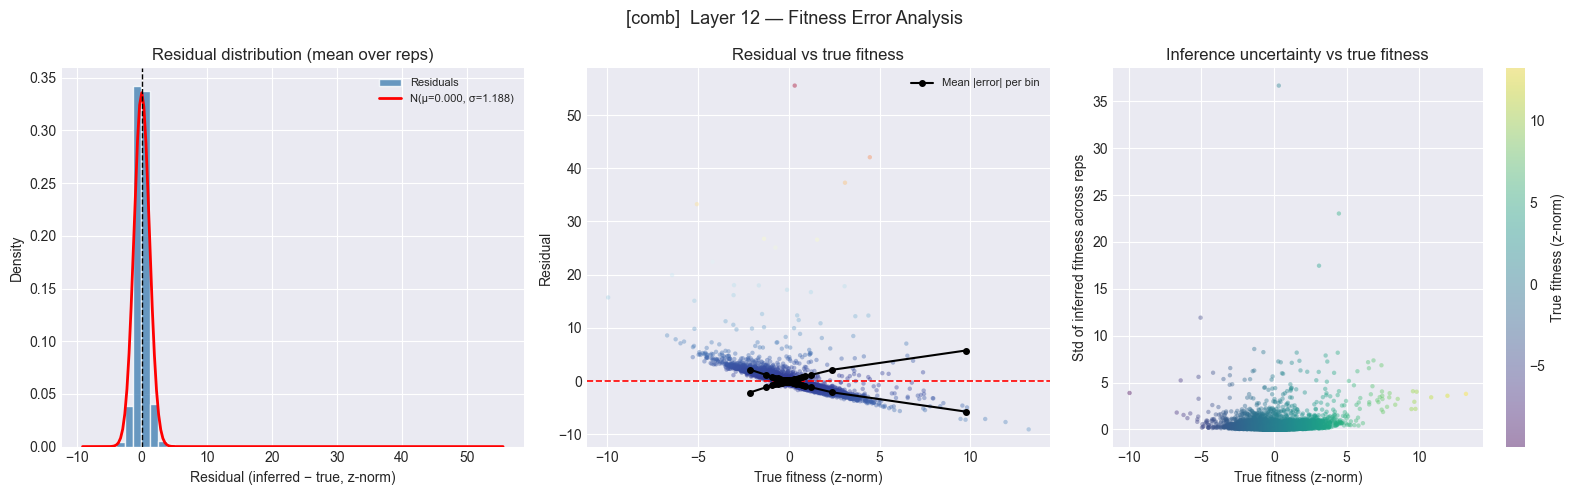

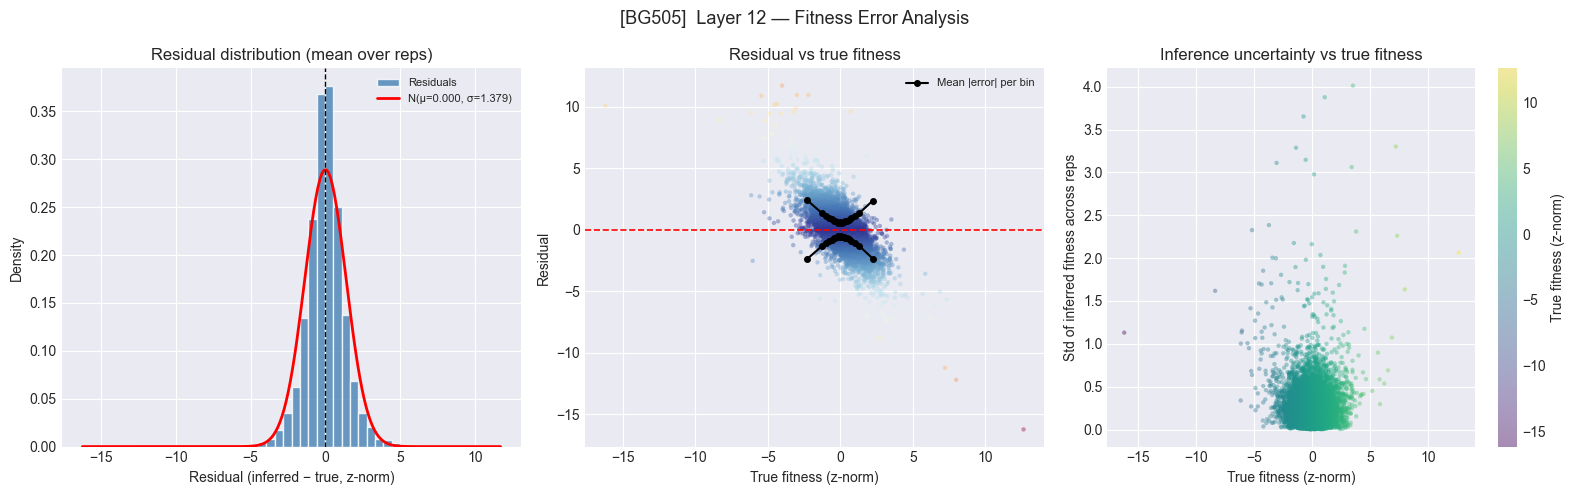

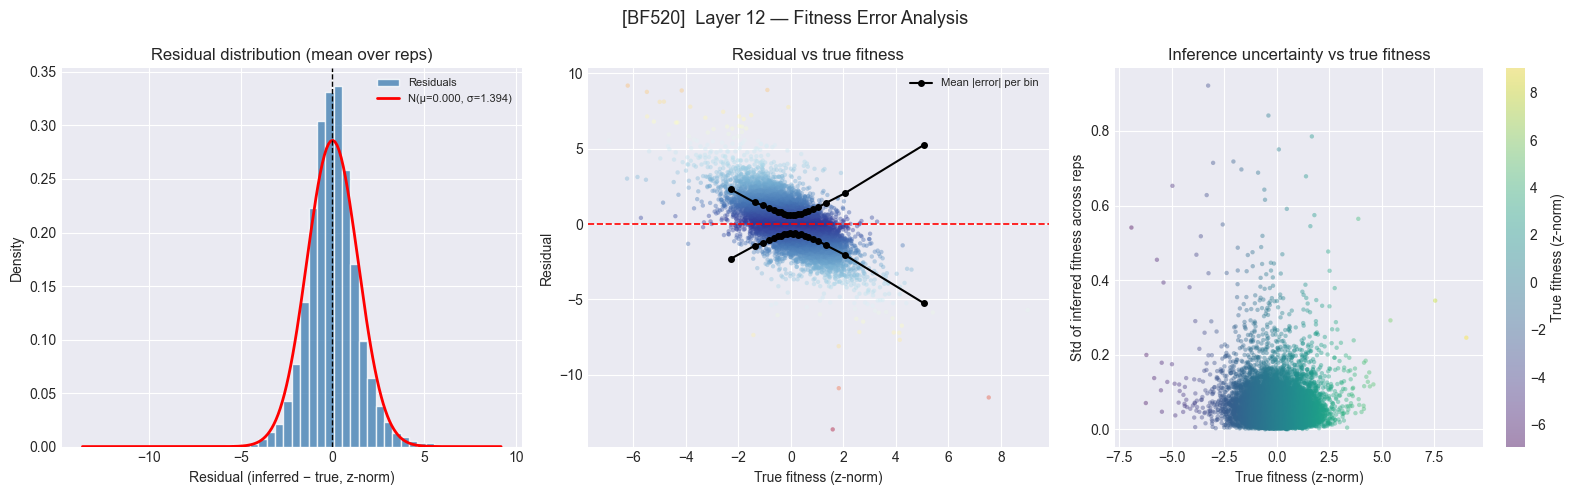

In [15]:
from scipy.stats import norm as scipy_norm

for path_name, layer_dict in fitness_data.items():
    for layer, fd in layer_dict.items():
        true_norm = z_normalize(fd['true'])
        n_reps    = fd['n_reps']

        # Average inferred fitness across replicates (mean-inferred)
        inf_mat   = np.column_stack([z_normalize(fd['inferred'][:, r]) for r in range(n_reps)])
        inf_mean  = inf_mat.mean(axis=1)
        residuals = inf_mean - true_norm  # shape (N,)

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # --- (1) Residual histogram with fitted Gaussian ---
        ax = axes[0]
        ax.hist(residuals, bins=50, density=True, color='steelblue',
                edgecolor='white', alpha=0.8, label='Residuals')
        mu, sigma = residuals.mean(), residuals.std()
        x_range = np.linspace(residuals.min(), residuals.max(), 200)
        ax.plot(x_range, scipy_norm.pdf(x_range, mu, sigma),
                'r-', linewidth=2, label=f'N(μ={mu:.3f}, σ={sigma:.3f})')
        ax.axvline(0, color='k', linestyle='--', linewidth=1)
        ax.set_xlabel('Residual (inferred − true, z-norm)')
        ax.set_ylabel('Density')
        ax.set_title('Residual distribution (mean over reps)')
        ax.legend(fontsize=8)

        # --- (2) Residual vs true fitness (heteroscedasticity check) ---
        ax = axes[1]
        ax.scatter(true_norm, residuals, alpha=0.4, s=10,
                   c=np.abs(residuals), cmap='RdYlBu_r', edgecolors='none')
        ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
        # Running mean of |residual| in bins
        sort_idx  = np.argsort(true_norm)
        bin_size  = max(1, len(true_norm) // 20)
        bin_means = [np.abs(residuals[sort_idx[i:i+bin_size]]).mean()
                     for i in range(0, len(sort_idx), bin_size)]
        bin_x     = [true_norm[sort_idx[i:i+bin_size]].mean()
                     for i in range(0, len(sort_idx), bin_size)]
        ax.plot(bin_x, bin_means, 'k-o', markersize=4, linewidth=1.5,
                label='Mean |error| per bin')
        ax.plot(bin_x, [-b for b in bin_means], 'k-o', markersize=4, linewidth=1.5)
        ax.set_xlabel('True fitness (z-norm)')
        ax.set_ylabel('Residual')
        ax.set_title('Residual vs true fitness')
        ax.legend(fontsize=8)

        # --- (3) Cross-replicate spread of inferred fitness ---
        ax = axes[2]
        if n_reps > 1:
            rep_std = inf_mat.std(axis=1)
            scatter = ax.scatter(true_norm, rep_std, alpha=0.4, s=10,
                                 c=true_norm, cmap='viridis', edgecolors='none')
            plt.colorbar(scatter, ax=ax, label='True fitness (z-norm)')
            ax.set_xlabel('True fitness (z-norm)')
            ax.set_ylabel('Std of inferred fitness across reps')
            ax.set_title('Inference uncertainty vs true fitness')
        else:
            ax.text(0.5, 0.5, 'Only 1 replicate — no spread to show',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_visible(True)

        fig.suptitle(f'[{path_name}]  Layer {layer} — Fitness Error Analysis', fontsize=13)
        plt.tight_layout()
        plt.show()


### Summary statistics table — all datasets and replicates

In [16]:
rows = []
for path_name, layer_dict in fitness_data.items():
    for layer, fd in layer_dict.items():
        true_norm = z_normalize(fd['true'])
        n_reps    = fd['n_reps']

        for rep in range(n_reps):
            inf_norm  = z_normalize(fd['inferred'][:, rep])
            r, pval   = pearsonr(true_norm, inf_norm)
            rho, _    = spearmanr(true_norm, inf_norm)
            rmse      = np.sqrt(np.mean((true_norm - inf_norm) ** 2))
            mae       = np.mean(np.abs(true_norm - inf_norm))
            bias      = np.mean(inf_norm - true_norm)
            rows.append(dict(Dataset=path_name, Layer=layer, Rep=rep+1,
                             Pearson_r=round(r, 4), Spearman_rho=round(rho, 4),
                             RMSE=round(rmse, 4), MAE=round(mae, 4),
                             Bias=round(bias, 4), p_value=f'{pval:.2e}'))

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))


Dataset  Layer  Rep  Pearson_r  Spearman_rho   RMSE    MAE  Bias  p_value
   comb     12    1     0.2385        0.3741 1.2341 0.6820   0.0 0.00e+00
   comb     12    2     0.3175        0.3246 1.1683 0.7131   0.0 0.00e+00
   comb     12    3     0.2545        0.3112 1.2211 0.7259   0.0 0.00e+00
   comb     12    4     0.0681        0.0826 1.3652 0.7278   0.0 1.05e-28
   comb     12    5     0.0132       -0.0339 1.4048 0.7113   0.0 3.11e-02
   comb     12    6     0.0107        0.0081 1.4066 0.7147   0.0 8.08e-02
  BG505     12    1     0.0054        0.0218 1.4104 0.9870   0.0 5.31e-01
  BG505     12    2     0.0032        0.0339 1.4119 0.9831   0.0 7.09e-01
  BG505     12    3     0.0028        0.0116 1.4122 0.9986   0.0 7.43e-01
  BF520     12    1     0.0235        0.0297 1.3975 1.0270   0.0 7.11e-03
  BF520     12    2     0.0257        0.0345 1.3959 1.0239   0.0 3.16e-03
  BF520     12    3     0.0250        0.0317 1.3964 1.0235  -0.0 4.15e-03


### Cross-dataset comparison — Pearson r and Spearman ρ bar chart

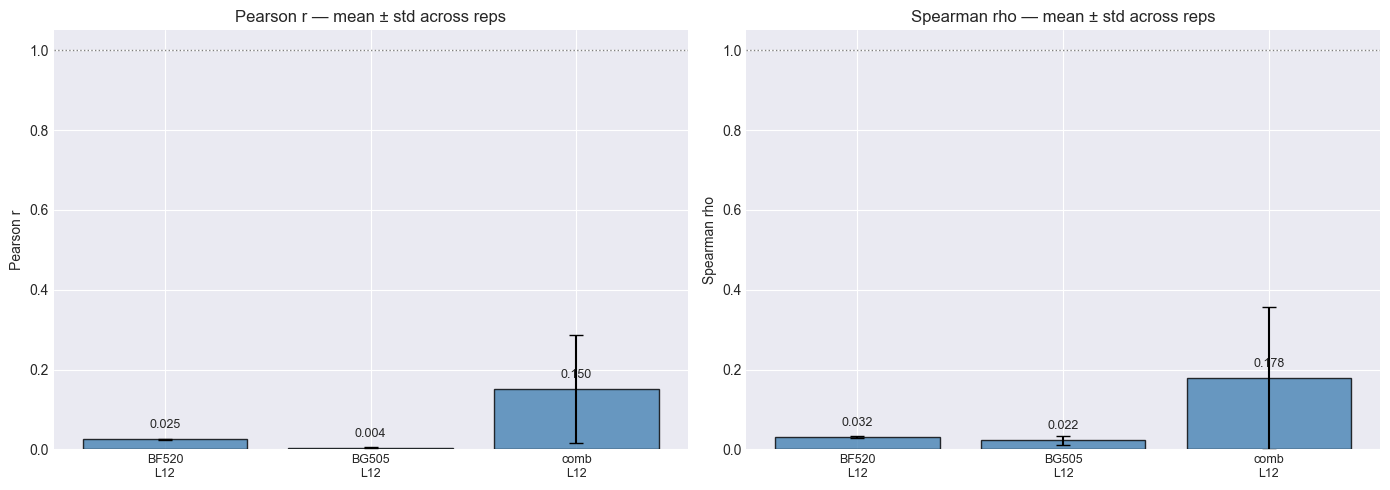

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['Pearson_r', 'Spearman_rho']):
    # Mean and std across replicates per (dataset, layer)
    agg = (summary_df
           .groupby(['Dataset', 'Layer'])[metric]
           .agg(['mean', 'std'])
           .reset_index())
    agg['label'] = agg.apply(lambda row: f"{row['Dataset']}\nL{row['Layer']}", axis=1)

    x    = np.arange(len(agg))
    bars = ax.bar(x, agg['mean'], yerr=agg['std'].fillna(0),
                  capsize=5, color='steelblue', edgecolor='k', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(agg['label'], fontsize=9)
    ax.set_ylabel(metric.replace('_', ' '))
    ax.set_title(f'{metric.replace("_", " ")} — mean ± std across reps')
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)

    for bar, val in zip(bars, agg['mean']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [5]:
final_df_bf = load_final_df(12, PATHS['BF520'])

In [8]:
final_df_bf_embeddings = np.vstack(final_df_bf['Embedding'].tolist())
print("Final DF embeddings shape:", final_df_bf_embeddings.shape)

Final DF embeddings shape: (13172, 640)


In [9]:
# Get the covariance matrix
cov_matrix = np.cov(final_df_bf_embeddings, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (640, 640)


In [10]:
cov_matrix

array([[ 3.47601698e-04, -8.05451373e-05,  8.44877020e-05, ...,
         9.77661429e-05,  2.24769438e-04, -1.28996902e-04],
       [-8.05451373e-05,  2.44131945e-04, -7.83005080e-05, ...,
        -4.02338260e-05, -6.81468904e-05,  6.75303389e-05],
       [ 8.44877020e-05, -7.83005080e-05,  2.15935917e-04, ...,
         5.73729051e-05,  8.16143899e-05, -2.05280294e-05],
       ...,
       [ 9.77661429e-05, -4.02338260e-05,  5.73729051e-05, ...,
         2.67748186e-04,  6.05369504e-05, -7.27079642e-05],
       [ 2.24769438e-04, -6.81468904e-05,  8.16143899e-05, ...,
         6.05369504e-05,  3.05901632e-04, -4.97754885e-05],
       [-1.28996902e-04,  6.75303389e-05, -2.05280294e-05, ...,
        -7.27079642e-05, -4.97754885e-05,  2.03826913e-04]],
      shape=(640, 640))

In [11]:
inverse_cov_matrix = np.linalg.inv(cov_matrix)

In [12]:
inverse_cov_matrix

array([[208566.4721691 ,   6871.71564478,   5321.95964612, ...,
         10272.9375092 , -21969.27004219,  21128.14003899],
       [  6871.71564478, 184318.07226431,  10596.55178317, ...,
          3854.14203462,  -6136.31487657,   8969.26774764],
       [  5321.95964612,  10596.55178317, 194415.09628891, ...,
          1908.0145231 ,  -2181.7269113 ,    546.83115374],
       ...,
       [ 10272.93750919,   3854.14203462,   1908.0145231 , ...,
        196223.06049165,  29672.47914683,   4275.87045668],
       [-21969.27004219,  -6136.31487657,  -2181.7269113 , ...,
         29672.47914683, 210348.20507606,   2410.37432126],
       [ 21128.14003899,   8969.26774764,    546.83115374, ...,
          4275.87045668,   2410.37432126, 195677.64545856]],
      shape=(640, 640))

## Error Bar Analysis

### Why `s_joint` Error Bars Are Sometimes NaN

The error bars for `s_joint` in `mini_infer_independent_esm` are computed as:

```python
s_joint_err_sub = np.sqrt(np.diag(np.linalg.inv(reg_joint)))
```

where `reg_joint = icov_sub_sum + n_\text{reps} \cdot \gamma \cdot I`.

`np.sqrt` returns `NaN` for negative inputs. NaN error bars occur whenever any diagonal entry of $(C + \gamma I)^{-1}$ is **negative**, which happens if and only if `reg_joint` is **not positive definite (PD)**.

For a PD matrix $A$, the quadratic form $\mathbf{e}_i^\top A^{-1} \mathbf{e}_i = (A^{-1})_{ii} > 0$ always holds. But if $A$ has a non-positive eigenvalue, $A^{-1}$ can have negative diagonal entries, making `sqrt` return NaN.

There are **two distinct causes**:

---

**Cause 1 — Numerical: `reg_joint` is not positive definite**

`reg_joint` is PD iff all eigenvalues of `icov_sub_sum` are $> -n_\text{reps} \cdot \gamma$. This fails when `icov_sub_sum` has eigenvalues more negative than $-n_\text{reps} \cdot \gamma$.

The `icov` diagonal (from `compute_dx_covariance_independent_esm`) contains terms of the form:

$$\text{icov}_{dd} \;\propto\; \sum_t \Delta t_t \cdot x_t[d] \cdot \left(\frac{1}{2} - \frac{x_t[d]}{3}\right)$$

This is **negative** when $x_t[d] > \tfrac{3}{2}$ or $x_t[d] < 0$ — both common for ESM embeddings, which are not bounded in $[0, 1]$. When $|\text{icov}_{dd}| > n_\text{reps} \cdot \gamma$, the diagonal of `reg_joint` becomes negative, making it non-PD $\Rightarrow$ NaN.

With a single replicate, $\gamma$ is hardcoded to 1. If any dimension has $\text{icov}_{dd} < -1$, NaN appears.

---

**Cause 2 — Intentional: `variance_cutoff > 0` with `infer_ignored_dims=False`**

When `variance_cutoff > 0`, low-variance dimensions are excluded from inference. The output array is initialized as:

```python
s_joint_error_bars = np.full(L, np.nan)
```

Only `kept_dims` are filled in; ignored dims remain NaN by design. This is expected behavior, not a numerical bug.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'esmDMS'))
from popDMS import compute_dx_covariance_independent_esm

print("Imports OK")


Imports OK


### Cause 1 Demonstration: Large Embedding Values → Non-PD `icov`

We build a minimal synthetic `embedding_df` and directly inspect the diagonal of `icov` and the eigenvalues of `reg_joint` under varying `gamma`.


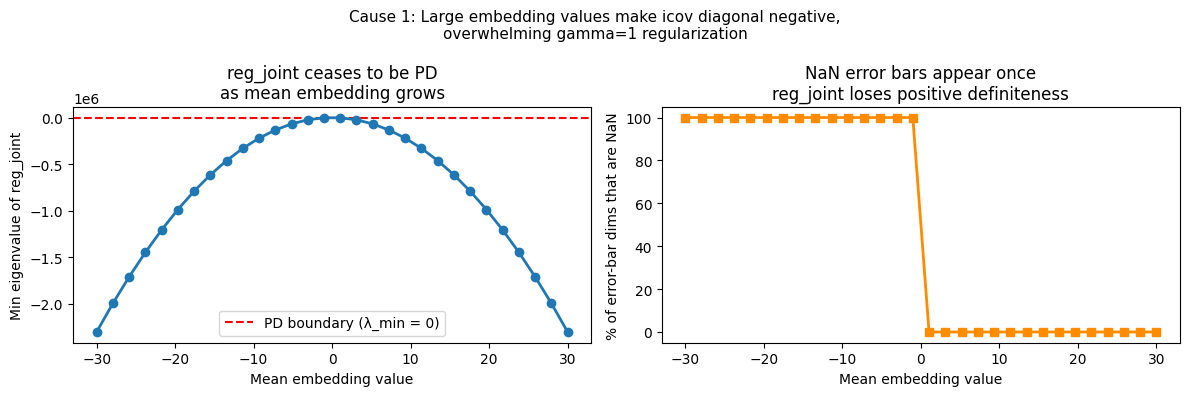

Critical mean_emb where NaN first appears: ~-30.00


In [33]:
import pandas as pd

rng = np.random.default_rng(42)

def make_embedding_df(n_variants, d, mean_emb, n_gens=3, n_reps=1, seed=0):
    """
    Build a synthetic embedding_df compatible with compute_dx_covariance_independent_esm.
    mean_emb: float, controls the typical magnitude of the embedding values.
    """
    rng = np.random.default_rng(seed)
    embeddings = rng.normal(loc=mean_emb, scale=1.0, size=(n_variants, d))
    rows = []
    for rep in range(1, n_reps + 1):
        # uniform initial counts, slight drift over generations
        counts = np.ones(n_variants) / n_variants
        for gen in range(n_gens):
            counts = counts + rng.normal(0, 0.01, n_variants)
            counts = np.abs(counts)
            counts /= counts.sum()
            for i in range(n_variants):
                rows.append({
                    "Generation": gen + 1,
                    "Embedding": embeddings[i],
                    "Frequency": counts[i],
                    "Replicate": rep,
                })
    return pd.DataFrame(rows)

# ── Scan mean embedding magnitudes ──────────────────────────────────────────
n_variants, d = 10000, 640
mean_emb_values = np.linspace(-30.0, 30.0, 30)
gamma = 1.0  # default for single replicate

min_eig_reg = []
frac_nan_errs = []

for mean_emb in mean_emb_values:
    df = make_embedding_df(n_variants, d, mean_emb, n_gens=5, n_reps=3, seed=7)
    dx, icov, _ = compute_dx_covariance_independent_esm(df)
    icov_sum = icov[0]  # single replicate
    reg = icov_sum + gamma * np.eye(d)
    eigs = np.linalg.eigvalsh(reg)
    min_eig_reg.append(eigs.min())
    # Simulate error bar calculation
    try:
        diag_inv = np.diag(np.linalg.inv(reg))
        n_nan = np.sum(diag_inv < 0)
    except np.linalg.LinAlgError:
        n_nan = d
    frac_nan_errs.append(n_nan / d)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].axhline(0, color='red', linestyle='--', lw=1.5, label='PD boundary (λ_min = 0)')
axes[0].plot(mean_emb_values, min_eig_reg, 'o-', lw=2)
axes[0].set_xlabel("Mean embedding value")
axes[0].set_ylabel("Min eigenvalue of reg_joint")
axes[0].set_title("reg_joint ceases to be PD\nas mean embedding grows")
axes[0].legend()

axes[1].plot(mean_emb_values, np.array(frac_nan_errs) * 100, 's-', color='darkorange', lw=2)
axes[1].set_xlabel("Mean embedding value")
axes[1].set_ylabel("% of error-bar dims that are NaN")
axes[1].set_title("NaN error bars appear once\nreg_joint loses positive definiteness")

plt.suptitle("Cause 1: Large embedding values make icov diagonal negative,\n"
             "overwhelming gamma=1 regularization", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Critical mean_emb where NaN first appears: "
      f"~{mean_emb_values[np.argmax(np.array(frac_nan_errs) > 0)]:.2f}")


### The `icov` Diagonal Formula — Sign Analysis

The diagonal integrand is $x_d(t)\bigl(1 - x_d(t)\bigr) = x_d\left(\tfrac{1}{2} - \tfrac{x_d}{3}\right) \cdot 2$, but more directly the per-step same-time contribution is $\texttt{dtsum}[i] \cdot \left(\tfrac{x_i}{2} - \tfrac{x_i^2}{3}\right)$. The factor $\left(\tfrac{1}{2} - \tfrac{x}{3}\right)$ changes sign at $x = 0$ and $x = \tfrac{3}{2}$:

$$\frac{x}{2} - \frac{x^2}{3} = x\left(\frac{1}{2} - \frac{x}{3}\right) \begin{cases} < 0 & x < 0 \text{ or } x > \tfrac{3}{2} \\ > 0 & 0 < x < \tfrac{3}{2} \end{cases}$$

We inspect this directly to show at what embedding magnitude the `icov` diagonal changes sign.


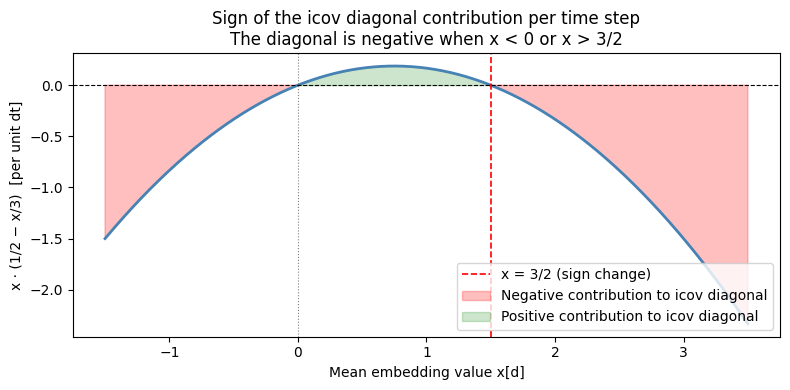

ESM embeddings typically span large ranges far outside [0, 3/2].
Any dimension whose mean embedding trajectory stays negative or > 1.5
accumulates a negative icov diagonal entry that gamma=1 may not overcome.


In [29]:

# icov diagonal (same-time term): dt * (x/2 - x^2/3) = dt * x * (1/2 - x/3)
# This is zero at x=0 and x=3/2, negative outside (0, 3/2)
x_vals = np.linspace(-1.5, 3.5, 500)
diag_factor = x_vals * (0.5 - x_vals / 3.0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_vals, diag_factor, lw=2, color='steelblue')
ax.axhline(0, color='k', lw=0.8, linestyle='--')
ax.axvline(0, color='gray', lw=0.8, linestyle=':')
ax.axvline(1.5, color='red', lw=1.2, linestyle='--', label='x = 3/2 (sign change)')
ax.fill_between(x_vals, diag_factor, 0,
                where=(diag_factor < 0), alpha=0.25, color='red',
                label='Negative contribution to icov diagonal')
ax.fill_between(x_vals, diag_factor, 0,
                where=(diag_factor >= 0), alpha=0.2, color='green',
                label='Positive contribution to icov diagonal')
ax.set_xlabel("Mean embedding value x[d]")
ax.set_ylabel("x · (1/2 − x/3)  [per unit dt]")
ax.set_title("Sign of the icov diagonal contribution per time step\n"
             "The diagonal is negative when x < 0 or x > 3/2")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("ESM embeddings typically span large ranges far outside [0, 3/2].")
print("Any dimension whose mean embedding trajectory stays negative or > 1.5")
print("accumulates a negative icov diagonal entry that gamma=1 may not overcome.")


### How Much Gamma Is Needed to Prevent NaN?

We sweep `gamma` and count how many dimensions produce NaN error bars, using a realistic embedding scenario (mean ~2.0, representative of ESM output).


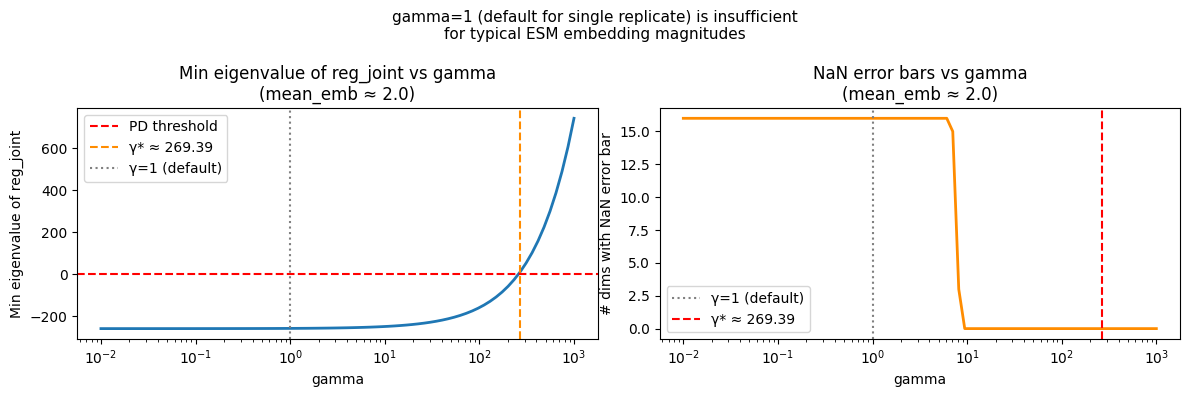

icov diagonal range:  [-27.056, -18.542]
icov eigenvalue range: [-258.557, -6.895]
gamma needed to make reg_joint PD: ~269.3889309590175
gamma used (single replicate default): 1.0


In [31]:

# Use a fixed df with mean embedding value ~2.0 (typical for ESM)
df_esm_like = make_embedding_df(n_variants=100, d=16, mean_emb=-2.0, n_gens=5, n_reps=1, seed=99)
dx_esm, icov_esm, _ = compute_dx_covariance_independent_esm(df_esm_like)
icov_sum_esm = icov_esm[0]

gammas = np.logspace(-2, 3, 80)
min_eigs = []
n_nan_per_gamma = []

for g in gammas:
    reg = icov_sum_esm + g * np.eye(icov_sum_esm.shape[0])
    eigs = np.linalg.eigvalsh(reg)
    min_eigs.append(eigs.min())
    diag_inv = np.diag(np.linalg.inv(reg))
    n_nan_per_gamma.append(np.sum(diag_inv < 0))

min_eigs = np.array(min_eigs)
n_nan_per_gamma = np.array(n_nan_per_gamma)

# gamma at which reg becomes PD
gamma_pd_threshold = gammas[np.argmax(min_eigs > 0)] if np.any(min_eigs > 0) else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogx(gammas, min_eigs, lw=2)
axes[0].axhline(0, color='red', linestyle='--', lw=1.5, label='PD threshold')
if gamma_pd_threshold is not None:
    axes[0].axvline(gamma_pd_threshold, color='darkorange', linestyle='--', lw=1.5,
                    label=f'γ* ≈ {gamma_pd_threshold:.2f}')
axes[0].axvline(1.0, color='gray', linestyle=':', lw=1.5, label='γ=1 (default)')
axes[0].set_xlabel("gamma")
axes[0].set_ylabel("Min eigenvalue of reg_joint")
axes[0].set_title("Min eigenvalue of reg_joint vs gamma\n(mean_emb ≈ 2.0)")
axes[0].legend()

axes[1].semilogx(gammas, n_nan_per_gamma, lw=2, color='darkorange')
axes[1].axvline(1.0, color='gray', linestyle=':', lw=1.5, label='γ=1 (default)')
if gamma_pd_threshold is not None:
    axes[1].axvline(gamma_pd_threshold, color='red', linestyle='--', lw=1.5,
                    label=f'γ* ≈ {gamma_pd_threshold:.2f}')
axes[1].set_xlabel("gamma")
axes[1].set_ylabel("# dims with NaN error bar")
axes[1].set_title("NaN error bars vs gamma\n(mean_emb ≈ 2.0)")
axes[1].legend()

plt.suptitle("gamma=1 (default for single replicate) is insufficient\n"
             "for typical ESM embedding magnitudes", fontsize=11)
plt.tight_layout()
plt.show()

print(f"icov diagonal range:  [{icov_sum_esm.diagonal().min():.3f}, {icov_sum_esm.diagonal().max():.3f}]")
print(f"icov eigenvalue range: [{np.linalg.eigvalsh(icov_sum_esm).min():.3f}, {np.linalg.eigvalsh(icov_sum_esm).max():.3f}]")
print(f"gamma needed to make reg_joint PD: ~{gamma_pd_threshold}")
print(f"gamma used (single replicate default): 1.0")


### Cause 2 Demonstration: Intentional NaN from `variance_cutoff`

When `variance_cutoff > 0` and `infer_ignored_dims=False`, low-variance dimensions are excluded from inference and their error bars are left as NaN in the pre-allocated output array. This is by design.


In [ ]:
from popDMS import mini_infer_independent_esm

# Build a df with clearly differentiated dimension variances
rng2 = np.random.default_rng(0)
n_variants2, d2 = 40, 8
# First 4 dims: high variance; last 4 dims: near-zero variance
emb_high = rng2.normal(0, 2.0, (n_variants2, 4))
emb_low  = rng2.normal(0, 0.01, (n_variants2, 4))
embeddings2 = np.hstack([emb_high, emb_low])

rows2 = []
counts2 = np.ones(n_variants2) / n_variants2
for gen in range(1, 4):
    counts2 = np.abs(counts2 + rng2.normal(0, 0.02, n_variants2))
    counts2 /= counts2.sum()
    for i in range(n_variants2):
        rows2.append({"Generation": gen, "Embedding": embeddings2[i],
                      "Frequency": counts2[i], "Replicate": 1})
df2 = pd.DataFrame(rows2)

# Run with variance_cutoff=0.99 (keep only top dims) and infer_ignored_dims=False
result = mini_infer_independent_esm(
    df2, n_replicates=1, calc_error_bars=True,
    variance_cutoff=0.99, infer_ignored_dims=False
)
s_joint_errs = result[8]

print("s_joint_error_bars:", np.round(s_joint_errs, 4))
print()

kept = np.where(~np.isnan(s_joint_errs))[0]
ignored = np.where(np.isnan(s_joint_errs))[0]
print(f"Kept dims  (have error bars): {kept}")
print(f"Ignored dims (NaN by design): {ignored}")
print()

# Show that the ignored dims are indeed the low-variance ones
all_emb = embeddings2
dim_vars = np.var(all_emb, axis=0)
print("Per-dim variances:", np.round(dim_vars, 4))
print("→ Dims 4–7 have near-zero variance and are excluded from inference,")
print("  so their error bars are NaN — this is intentional, not a numerical bug.")


s_joint_error_bars: [0.9715 0.8457 1.4274 0.8918    nan    nan    nan    nan]

Kept dims  (have error bars): [0 1 2 3]
Ignored dims (NaN by design): [4 5 6 7]

Per-dim variances: [3.0306e+00 3.1261e+00 4.0952e+00 4.4686e+00 1.0000e-04 1.0000e-04
 1.0000e-04 2.0000e-04]
→ Dims 4–7 have near-zero variance and are excluded from inference,
  so their error bars are NaN — this is intentional, not a numerical bug.


### End-to-End Verification via `get_simulation_results`

Confirm both causes appear in an actual simulation run by checking the NaN fraction of `s_joint_error_bars` returned from `get_simulation_results`.


In [32]:

# ── Reproduce Cause 1 end-to-end with a single replicate, no variance_cutoff ─
# We directly call mini_infer_independent_esm on our "ESM-like" df
# (mean_emb=2.0, single replicate, gamma fixed at 1)
result_e2e = mini_infer_independent_esm(
    df_esm_like, n_replicates=1, gamma=1.0,
    calc_error_bars=True, variance_cutoff=0.0
)
s_joint_errs_e2e = result_e2e[8]

n_nan = np.sum(np.isnan(s_joint_errs_e2e))
n_total = len(s_joint_errs_e2e)
print(f"[Cause 1] gamma=1, mean_emb~2: {n_nan}/{n_total} error bars are NaN")

# Now raise gamma enough to make reg_joint PD
# (use the threshold found above, rounded up)
safe_gamma = float(gamma_pd_threshold) * 2 if gamma_pd_threshold else 100.0
result_safe = mini_infer_independent_esm(
    df_esm_like, n_replicates=1, gamma=safe_gamma,
    calc_error_bars=True, variance_cutoff=0.0
)
s_joint_errs_safe = result_safe[8]
n_nan_safe = np.sum(np.isnan(s_joint_errs_safe))
print(f"[Cause 1] gamma={safe_gamma:.1f} (> threshold): {n_nan_safe}/{n_total} error bars are NaN")

print()
print("Summary of the two NaN causes:")
print("  Cause 1 (numerical): gamma too small → reg_joint not PD → sqrt(negative) = NaN")
print("  Cause 2 (intentional): variance_cutoff excludes dims → pre-allocated NaN stays")


[Cause 1] gamma=1, mean_emb~2: 16/16 error bars are NaN
[Cause 1] gamma=538.8 (> threshold): 0/16 error bars are NaN

Summary of the two NaN causes:
  Cause 1 (numerical): gamma too small → reg_joint not PD → sqrt(negative) = NaN
  Cause 2 (intentional): variance_cutoff excludes dims → pre-allocated NaN stays


/Users/dylanwells/popDMS/esmDMS/popDMS.py:1499: RuntimeWarning: invalid value encountered in sqrt
  err_sub[r_idx] = np.sqrt(np.diag(np.linalg.inv(reg)))
/Users/dylanwells/popDMS/esmDMS/popDMS.py:1506: RuntimeWarning: invalid value encountered in sqrt
  s_joint_err_sub = np.sqrt(np.diag(np.linalg.inv(reg_joint)))


### Summary

| Cause | Trigger | Symptom | Numerical bug? |
|-------|---------|---------|----------------|
| **1. Non-PD `reg_joint`** | Mean embedding trajectory $x_d(t)$ stays outside $(0, \tfrac{3}{2})$, making $\Sigma_{dd} < 0$. With $n_\text{reps}=1$ and $\gamma=1$ fixed, this is not overcome. | $\sqrt{[(\Sigma+\gamma I)^{-1}]_{dd}}$ is NaN for affected dims | **Yes** — error bars are meaningless |
| **2. `variance_cutoff` exclusion** | `variance_cutoff > 0` AND `infer_ignored_dims=False` | Ignored dims stay as `np.nan` from pre-allocation | **No** — intentional by design |

**Root cause in plain terms:**
The $\Sigma_{dd}$ formula was derived for allele/barcode frequencies bounded in $[0, 1]$. ESM embeddings are real-valued features that routinely fall outside $(0, \tfrac{3}{2})$, making the diagonal term $x_d(1 - x_d)$ negative. When the accumulated negative diagonal exceeds $n_\text{reps} \cdot \gamma$, the matrix $\Sigma + \gamma I$ loses positive definiteness, its inverse has negative diagonal entries, and $\sqrt{\cdot}$ returns NaN.

**The multi-replicate case naturally mitigates Cause 1** because $\gamma$ is chosen by cross-replicate correlation maximization (typically larger values) and the $n_\text{reps}$ multiplier on $\gamma I$ provides extra regularization.


---
## Deep Dive: Math of `compute_dx_covariance_independent_esm`

This section derives every line of `compute_dx_covariance_independent_esm` from first principles. The function is the bridge between raw population counts and the linear system $\Delta\mathbf{x} = C \cdot \mathbf{s}$ that popDMS solves for selection coefficients $\mathbf{s}$.

---

### Setup and notation

We have a population of $N$ variants, each described by an embedding vector $\boldsymbol{\phi}_\alpha \in \mathbb{R}^d$. At time $t$, variant $\alpha$ has frequency $f_\alpha(t) \geq 0$, with $\sum_\alpha f_\alpha(t) = 1$.

The **mean embedding** at time $t$ is the frequency-weighted average over all variants:

$$\mathbf{x}(t) = \sum_\alpha f_\alpha(t)\, \boldsymbol{\phi}_\alpha \;\in\; \mathbb{R}^d$$

The code tracks $\mathbf{x}(t)$ at a finite set of observed time points $t_0 < t_1 < \cdots < t_T$.


### Step 1 — Selection model and the equation of motion

Under continuous-time Wright-Fisher dynamics with selection, the frequency of variant $\alpha$ evolves as:

$$\frac{df_\alpha}{dt} = f_\alpha(t)\bigl(F_\alpha - \langle F \rangle(t)\bigr)$$

where $F_\alpha = \boldsymbol{\phi}_\alpha \cdot \mathbf{s}$ is the fitness of variant $\alpha$ and $\langle F \rangle(t) = \sum_\beta f_\beta(t) F_\beta = \mathbf{x}(t) \cdot \mathbf{s}$ is the population mean fitness.

Taking the time derivative of the $d$-th component of the mean embedding:

$$\frac{dx_d}{dt} = \sum_\alpha \phi_\alpha[d]\,\frac{df_\alpha}{dt}
= \sum_e s_e \underbrace{\left[\sum_\alpha f_\alpha\,\phi_\alpha[d]\,\phi_\alpha[e] - x_d(t)\,x_e(t)\right]}_{C_{de}(t)}$$

where $C_{de}(t)$ is the **covariance** of the embedding distribution at time $t$:

$$C_{de}(t) = \underbrace{\sum_\alpha f_\alpha(t)\,\phi_\alpha[d]\,\phi_\alpha[e]}_{\mathbb{E}[\phi_d\phi_e](t)} - x_d(t)\,x_e(t)$$

In matrix form, $\dot{\mathbf{x}} = C(t)\,\mathbf{s}$. Integrating from $t_0$ to $t_T$:

$$\Delta\mathbf{x} \;\equiv\; \mathbf{x}(t_T) - \mathbf{x}(t_0) \;=\; \underbrace{\left[\int_{t_0}^{t_T} C(t)\,dt\right]}_{\Sigma}\,\mathbf{s}$$

The **integrated covariance** $\Sigma = \int C(t)\,dt$ is a $d \times d$ positive-semidefinite matrix. Given $\Delta\mathbf{x}$ and $\Sigma$, the maximum-likelihood selection coefficients are $\mathbf{s} = \Sigma^{-1}\Delta\mathbf{x}$. Regularization adds $\gamma I$ to prevent overfitting when $\Sigma$ is ill-conditioned.


### Step 2 — The "independent sites" approximation for ESM embeddings

Computing the full covariance $C_{de}(t) = \sum_\alpha f_\alpha \phi_\alpha[d]\phi_\alpha[e] - x_d x_e$ requires tracking all pairwise embedding products across variants. In the ESM setting the code applies an **independent-sites approximation**: it treats the $d$-dimensional mean embedding $\mathbf{x}(t)$ as if its components were independent barcode frequencies.

In the barcode case, each barcode $i$ has frequency $f_i(t)$ and the exact multinomial covariance is:

$$C_{ii}(t) = f_i(t)\bigl(1 - f_i(t)\bigr) \qquad\text{(diagonal / variance)}$$
$$C_{ij}(t) = -f_i(t)\,f_j(t) \qquad\text{(off-diagonal, from the constraint } \textstyle\sum_i f_i = 1\text{)}$$

In the ESM extension, the code substitutes $f_i(t) \to x_d(t)$, treating the mean embedding in each dimension as the "frequency" of that dimension:

$$C_{dd}(t) \;\approx\; x_d(t)\,\bigl(1 - x_d(t)\bigr) \qquad\text{(diagonal)}$$
$$C_{de}(t) \;\approx\; -x_d(t)\,x_e(t) \qquad d \neq e \quad\text{(off-diagonal)}$$

This is why the function is named `...independent_esm`. The $\sum_\alpha f_\alpha \phi_\alpha[d]\phi_\alpha[e]$ term is absorbed into the diagonal (as if each dimension were an independent allele with "frequency" $x_d$), and the off-diagonal captures only the mean-product cross-term.


### Step 3 — Exact integration of piecewise-linear trajectories

We only observe $\mathbf{x}(t)$ at the discrete times $t_0, t_1, \ldots, t_T$. Between measurements, the code assumes $\mathbf{x}(t)$ varies **linearly** on each interval $[t_k, t_{k+1}]$. This allows the integrals $\int x_d\,dt$ and $\int x_d(t)\,x_e(t)\,dt$ to be computed **exactly** — not just approximately via the trapezoidal rule.

**Key result:** for two functions $f(t)$ and $g(t)$ that are linear on $[t_k, t_{k+1}]$ with endpoint values $(p, q)$ and $(r, s)$ respectively:

$$\int_{t_k}^{t_{k+1}} f(t)\,g(t)\,dt \;=\; \Delta t_k\left[\frac{p\,r + q\,s}{3} + \frac{p\,s + q\,r}{6}\right]$$

This differs from the trapezoidal rule (which gives $\Delta t_k\,\frac{pr+qs}{2}$) because the product of two linear functions is **quadratic**, not linear. The $1/3$ terms involve products at the **same** endpoint; the $1/6$ terms involve products **across** endpoints. This same-time / cross-time split is exactly how the code organises the icov computation.

**Integration of a single linear function** (needed for $\int x_d\,dt$):

$$\int_{t_k}^{t_{k+1}} f(t)\,dt \;=\; \Delta t_k\,\frac{p + q}{2}$$

This is the standard trapezoidal rule, exact for linear functions.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Verify the piecewise-linear product integral formula ────────────────────
# ∫₀^dt f(t)g(t) dt  where f and g are linear
# f: from p to q,  g: from r to s,  over interval [0, dt]

def exact_linear_product_integral(p, q, r, s, dt):
    """
    Analytical formula: dt * [(p*r + q*s)/3 + (p*s + q*r)/6]
    """
    return dt * ((p*r + q*s)/3 + (p*s + q*r)/6)

def numerical_linear_product_integral(p, q, r, s, dt, n=10000):
    """
    Numerical ground truth via dense quadrature.
    """
    t = np.linspace(0, dt, n)
    f = p + (q - p) * t / dt
    g = r + (s - r) * t / dt
    return np.trapz(f * g, t)

# Test a range of endpoint values
cases = [
    (0.2, 0.8, 0.5, 0.3, 1.0),   # typical barcode frequencies
    (2.0, 2.5, -1.0, 1.0, 2.0),  # typical ESM embeddings (outside [0,1])
    (0.0, 1.0, 0.0, 1.0, 1.0),   # ramp from 0 to 1
    (-0.5, 0.5, -0.5, 0.5, 1.0), # centered around zero
]

print(f"{'p':>6} {'q':>6} {'r':>6} {'s':>6} {'dt':>5}  {'formula':>12}  {'numerical':>12}  {'match?':>8}")
print("-" * 70)
for p, q, r, s, dt in cases:
    formula = exact_linear_product_integral(p, q, r, s, dt)
    numerical = numerical_linear_product_integral(p, q, r, s, dt)
    match = np.isclose(formula, numerical, rtol=1e-5)
    print(f"{p:6.2f} {q:6.2f} {r:6.2f} {s:6.2f} {dt:5.1f}  {formula:12.6f}  {numerical:12.6f}  {'✓' if match else '✗':>8}")


### Step 4 — The `dtsum` weights: collapsing same-time terms across intervals

When summing the same-time terms over all intervals $[t_k, t_{k+1}]$, each interior time point $t_i$ appears as the **right** endpoint of $[t_{i-1}, t_i]$ (contributing $\Delta t_{i-1}/3 \cdot x_i[d]\,x_i[e]$) and as the **left** endpoint of $[t_i, t_{i+1}]$ (contributing $\Delta t_i/3 \cdot x_i[d]\,x_i[e]$). Combining:

$$\text{same-time contribution at interior }i:\quad \frac{\Delta t_{i-1} + \Delta t_i}{3}\,x_i[d]\,x_i[e] \;=\; \frac{\texttt{dtsum}[i]}{3}\,x_i[d]\,x_i[e]$$

The code defines:

```python
dtsum = [t[1]-t[0]]                                     # first point: only right-endpoint
      + [t[i+1]-t[i-1] for i in range(1, len(t)-1)]    # interior: Δt_{i-1} + Δt_i
      + [t[-1]-t[-2]]                                    # last point: only left-endpoint
```

So $\texttt{dtsum}[i]/3$ is the exact weight for the same-time contribution to $\int x_d\,x_e\,dt$, and $\texttt{dtsum}[i]/2$ is the trapezoidal weight for $\int x_d\,dt$. Cross-time terms cannot be collapsed this way because each involves values at two *different* time points.


In [ ]:

# ── Visualise the dtsum weights for an example time grid ────────────────────
times_ex = np.array([0, 2, 5, 6, 10], dtype=float)
dtsum_ex = np.array(
    [times_ex[1] - times_ex[0]]
    + [times_ex[i+1] - times_ex[i-1] for i in range(1, len(times_ex)-1)]
    + [times_ex[-1] - times_ex[-2]]
)

fig, ax = plt.subplots(figsize=(9, 3))
for i, (t, w) in enumerate(zip(times_ex, dtsum_ex)):
    ax.bar(t, w/3, width=0.3, color='steelblue', alpha=0.8, label='dtsum[i]/3' if i == 0 else '')
    # mark the two intervals that contribute
    if i > 0:
        ax.annotate('', xy=(times_ex[i-1], w/3 * 0.45), xytext=(t, w/3 * 0.45),
                    arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
    if i < len(times_ex) - 1:
        ax.annotate('', xy=(t, w/3 * 0.6), xytext=(times_ex[i+1], w/3 * 0.6),
                    arrowprops=dict(arrowstyle='<->', color='coral', lw=1.2))

ax.set_xlabel("Time")
ax.set_ylabel("dtsum[i] / 3\n(same-time weight for ∫ x_d x_e dt)")
ax.set_title("dtsum[i] = (left interval width) + (right interval width)\n"
             "so dtsum[i]/3 is the exact same-time integration weight for x_d(t_i) x_e(t_i)")
ax.set_xticks(times_ex)
ax.set_xticklabels([f"t_{i}\n={int(t)}" for i, t in enumerate(times_ex)])
plt.tight_layout()
plt.show()

print("times:", times_ex)
print("dtsum:", dtsum_ex)
print("dtsum/3 (same-time weights for ∫ x_d x_e dt):", np.round(dtsum_ex/3, 4))
print("dtsum/2 (trapezoidal weights for ∫ x_d dt):", np.round(dtsum_ex/2, 4))
print("Sum check: dtsum/2 should equal total duration =", times_ex[-1] - times_ex[0],
      "→", dtsum_ex.sum()/2)


### Step 5 — Full formula for `icov`: off-diagonal and diagonal

Putting Steps 2–4 together, the integrated covariance matrix is:

**Off-diagonal entries** ($d \neq e$):

$$\Sigma_{de} = -\int x_d(t)\,x_e(t)\,dt$$

$$= -\sum_i \frac{\texttt{dtsum}[i]}{3}\,x_i[d]\,x_i[e] \quad\longleftarrow\text{same-time (code line A)}$$
$$\quad -\sum_k \frac{\Delta t_k}{6}\,\bigl(x_{k-1}[d]\,x_k[e] + x_k[d]\,x_{k-1}[e]\bigr) \quad\longleftarrow\text{cross-time (code line B)}$$

**Diagonal entries** ($d = d$):

$$\Sigma_{dd} = \int x_d(t)\,\bigl(1 - x_d(t)\bigr)\,dt = \int x_d\,dt - \int x_d^2\,dt$$

Expanding each integral into same-time and cross-time parts:

$$\int x_d\,dt = \sum_i \frac{\texttt{dtsum}[i]}{2}\,x_i[d]$$

$$\int x_d^2\,dt = \underbrace{\sum_i \frac{\texttt{dtsum}[i]}{3}\,x_i[d]^2}_{\text{same-time}} + \underbrace{\sum_k \frac{\Delta t_k}{3}\,x_{k-1}[d]\,x_k[d]}_{\text{cross-time}}$$

Therefore:

$$\Sigma_{dd} = \sum_i \texttt{dtsum}[i]\left(\frac{x_i[d]}{2} - \frac{x_i[d]^2}{3}\right) \quad\longleftarrow\text{code line C, overwrites diagonal}$$
$$\qquad\quad - \sum_k \frac{\Delta t_k}{3}\,x_{k-1}[d]\,x_k[d] \quad\longleftarrow\text{code line D, subtracts from diagonal}$$

**Note:** Lines A+B fill the entire matrix (including a temporarily wrong diagonal). Lines C+D then **overwrite** the diagonal with the correct formula. This is why the code comment reads *"note: diagonals will temporarily be incorrect"*.


### Step 6 — Full walkthrough demonstration

We build a tiny example from scratch (3 variants, 2 embedding dimensions, 4 time points) and compute `dx` and `icov` manually step by step, then verify against the code.


In [ ]:
import numpy as np
import pandas as pd

# ────────────────────────────────────────────────────────────────────────────
# Toy setup: 3 variants, d=2 embedding dimensions, 4 time points, 1 replicate
# ────────────────────────────────────────────────────────────────────────────

# Embedding vectors for 3 variants  (shape: 3 × 2)
embeddings = np.array([
    [1.0,  0.5],   # variant A
    [2.0, -1.0],   # variant B
    [0.5,  2.0],   # variant C
])

# Frequencies at each of the 4 time points  (shape: 4 × 3, rows must sum to 1)
freqs = np.array([
    [0.6,  0.3,  0.1],   # t=0
    [0.5,  0.35, 0.15],  # t=2
    [0.4,  0.4,  0.2],   # t=5
    [0.3,  0.45, 0.25],  # t=8
])
assert np.allclose(freqs.sum(axis=1), 1.0), "Frequencies must sum to 1 at each time"

times = np.array([0.0, 2.0, 5.0, 8.0])

# ── Step 1: Compute mean embedding x(t) at each time point ──────────────────
# x[i] = Σ_α f_α(t_i) · φ_α   (shape: 4 × 2)
x = freqs @ embeddings   # matrix multiply: (4×3) @ (3×2) = (4×2)

print("Mean embedding trajectory x(t):")
print("  Time   x[0]     x[1]")
for i, t in enumerate(times):
    print(f"  t={t:.0f}:  {x[i,0]:.4f}   {x[i,1]:.4f}")


In [ ]:

# ── Step 2: dx — change in mean embedding ───────────────────────────────────
dx_manual = x[-1] - x[0]
print("dx = x(t_T) - x(t_0) =", dx_manual)
print()

# ── Step 3: dtsum weights ────────────────────────────────────────────────────
T = len(times)
dtsum = np.array(
    [times[1] - times[0]]
    + [times[i+1] - times[i-1] for i in range(1, T-1)]
    + [times[-1] - times[-2]]
)
print("Time intervals (dt_k):", np.diff(times))
print("dtsum weights:        ", dtsum)
print()
print("Interpretation:")
for i, (t, w) in enumerate(zip(times, dtsum)):
    prev_dt = f"dt_{i-1}={times[i]-times[i-1]:.0f}" if i > 0 else "—"
    next_dt = f"dt_{i}={times[i+1]-times[i]:.0f}"   if i < T-1 else "—"
    print(f"  t_{i}={t:.0f}: dtsum={w:.0f} = {prev_dt} + {next_dt}")


In [ ]:

# ── Step 4: Build icov manually, line by line, matching the code ─────────────

d = 2   # embedding dimension
icov_manual = np.zeros((d, d))

# ── Line A: off-diagonal same-time terms ─────────────────────────────────────
# icov -= Σ_i  dtsum[i]/3 · outer(x[i], x[i])
# (fills entire matrix; diagonal will be wrong and gets overwritten later)
print("=== Line A: same-time off-diagonal (+ temporary diagonal) ===")
print("Formula: icov[d,e] -= Σ_i  dtsum[i]/3 · x_i[d] · x_i[e]")
icov_manual = np.tensordot(dtsum, -np.array([np.outer(x[i], x[i])/3 for i in range(T)]), axes=1)
print("icov after Line A (diagonal is WRONG here):\n", np.round(icov_manual, 5))
print()

# ── Line B: cross-time off-diagonal terms ────────────────────────────────────
# icov -= Σ_k  dt_k/6 · (outer(x_{k-1}, x_k) + outer(x_k, x_{k-1}))
print("=== Line B: cross-time off-diagonal ===")
print("Formula: icov[d,e] -= Σ_k  dt_k/6 · (x_{k-1}[d]·x_k[e] + x_k[d]·x_{k-1}[e])")
print()
for k in range(1, T):
    dt_k = times[k] - times[k-1]
    contrib = dt_k * (np.outer(x[k-1], x[k]) + np.outer(x[k], x[k-1])) / 6
    icov_manual -= contrib
    print(f"  k={k}: dt={dt_k:.0f},  cross-time contribution to [0,1]={contrib[0,1]:.5f}")
print("icov after Line B (off-diagonal now correct; diagonal still wrong):\n",
      np.round(icov_manual, 5))
print()

# ── Line C: diagonal overwrite — same-time part ──────────────────────────────
# icov[d,d] = Σ_i  dtsum[i] · (x_i[d]/2 - x_i[d]²/3)
#           = ∫ x_d dt  -  ∫ x_d² dt  (same-time contribution)
print("=== Line C: diagonal same-time overwrite ===")
print("Formula: icov[d,d] = Σ_i  dtsum[i] · (x_i[d]/2 − x_i[d]²/3)")
diag_same_time = dtsum.dot(x/2 - x**2/3)
print(f"  Dimension 0: Σ dtsum·(x/2-x²/3) = {diag_same_time[0]:.5f}")
print(f"  Dimension 1: Σ dtsum·(x/2-x²/3) = {diag_same_time[1]:.5f}")
icov_manual[np.diag_indices_from(icov_manual)] = diag_same_time
print("icov after Line C (diagonal correct for same-time part):\n", np.round(icov_manual, 5))
print()

# ── Line D: diagonal cross-time correction ───────────────────────────────────
# icov[d,d] -= Σ_k  dt_k/3 · x_{k-1}[d] · x_k[d]
print("=== Line D: diagonal cross-time correction ===")
print("Formula: icov[d,d] -= Σ_k  dt_k/3 · x_{k-1}[d] · x_k[d]")
for k in range(1, T):
    dt_k = times[k] - times[k-1]
    icov_manual[np.diag_indices_from(icov_manual)] -= dt_k * (x[k] * x[k-1]) / 3
print("icov FINAL (diagonal fully correct):\n", np.round(icov_manual, 5))


In [ ]:

# ── Verify against the actual code ──────────────────────────────────────────
from popDMS import compute_dx_covariance_independent_esm

# Build the embedding_df in the format the function expects
rows = []
for i, t in enumerate(times):
    for alpha in range(len(embeddings)):
        rows.append({
            "Generation": t,
            "Embedding": embeddings[alpha],
            "Frequency": freqs[i, alpha],
            "Replicate": 1,
        })
df_toy = pd.DataFrame(rows)

dx_code, icov_code, x_code = compute_dx_covariance_independent_esm(df_toy)

print("=== Verification: manual vs code ===")
print()
print("dx (manual):", np.round(dx_manual, 6))
print("dx (code):  ", np.round(dx_code[0], 6))
print("dx match:", np.allclose(dx_manual, dx_code[0]))
print()
print("icov (manual):\n", np.round(icov_manual, 6))
print("icov (code):\n",   np.round(icov_code[0], 6))
print("icov match:", np.allclose(icov_manual, icov_code[0]))
print()
print("x trajectory (manual):\n", np.round(x, 5))
print("x trajectory (code):\n",   np.round(x_code[0], 5))
print("x match:", np.allclose(x, x_code[0]))


In [ ]:

# ── Cross-check: numerically integrate the covariance directly ───────────────
# Build dense time grid, interpolate x(t), compute ∫ C(t) dt numerically
# This is the "ground truth" that the piecewise-linear formulas should match.

t_dense = np.linspace(times[0], times[-1], 10000)

# Interpolate x(t) linearly between observed time points
x_dense = np.zeros((len(t_dense), d))
for dim in range(d):
    x_dense[:, dim] = np.interp(t_dense, times, x[:, dim])

# Compute C(t) at each dense time point and integrate
# C_de(t) = -x_d(t) x_e(t) for off-diagonal  (independent-sites approximation)
# C_dd(t) =  x_d(t)(1 - x_d(t)) for diagonal

dt_dense = t_dense[1] - t_dense[0]
icov_numerical = np.zeros((d, d))
for di in range(d):
    for dj in range(d):
        if di == dj:
            icov_numerical[di, dj] = np.trapz(x_dense[:, di] * (1 - x_dense[:, di]), t_dense)
        else:
            icov_numerical[di, dj] = np.trapz(-x_dense[:, di] * x_dense[:, dj], t_dense)

print("icov (numerical ground truth, dense quadrature):")
print(np.round(icov_numerical, 6))
print()
print("icov (piecewise-linear formula, i.e., the code):")
print(np.round(icov_manual, 6))
print()
print("Max absolute difference:", np.max(np.abs(icov_numerical - icov_manual)))
print("Match to 4 decimal places:", np.allclose(icov_numerical, icov_manual, atol=1e-4))


In [ ]:

# ── Visual: plot x(t) and the instantaneous covariance C(t) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# x(t) trajectory
axes[0].plot(t_dense, x_dense[:, 0], label='$x_0(t)$ (dim 0)', lw=2)
axes[0].plot(t_dense, x_dense[:, 1], label='$x_1(t)$ (dim 1)', lw=2)
axes[0].scatter(times, x[:, 0], zorder=5, color='C0')
axes[0].scatter(times, x[:, 1], zorder=5, color='C1')
axes[0].axhline(0, color='k', lw=0.7, linestyle='--')
axes[0].axhline(1.5, color='gray', lw=0.7, linestyle=':', label='x=3/2 (sign change for diag)')
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Mean embedding x_d(t)")
axes[0].set_title("Mean embedding trajectory\n(dots = observed, line = piecewise-linear)")
axes[0].legend(fontsize=8)

# Diagonal covariance: C_dd(t) = x_d(t)(1 - x_d(t))
for dim in range(d):
    C_diag = x_dense[:, dim] * (1 - x_dense[:, dim])
    axes[1].plot(t_dense, C_diag, label=f'$C_{{{dim}{dim}}}(t) = x_{dim}(1-x_{dim})$', lw=2)
axes[1].axhline(0, color='k', lw=0.8, linestyle='--', label='zero')
axes[1].fill_between(t_dense,
                     x_dense[:, 1] * (1 - x_dense[:, 1]), 0,
                     where=(x_dense[:, 1] * (1 - x_dense[:, 1]) < 0),
                     alpha=0.3, color='red', label='negative C (→ non-PD icov)')
axes[1].set_xlabel("Time")
axes[1].set_title("Diagonal covariance C_dd(t)\n(negative when x_d < 0 or x_d > 1)")
axes[1].legend(fontsize=8)

# Off-diagonal covariance: C_01(t) = -x_0(t) x_1(t)
C_offdiag = -x_dense[:, 0] * x_dense[:, 1]
axes[2].plot(t_dense, C_offdiag, color='C2', lw=2, label='$C_{01}(t) = -x_0 x_1$')
axes[2].axhline(0, color='k', lw=0.8, linestyle='--')
axes[2].set_xlabel("Time")
axes[2].set_title("Off-diagonal covariance C_01(t)\n= negative product of mean embeddings")
axes[2].legend(fontsize=8)

plt.suptitle("Toy example: covariance integrand shapes", fontsize=11)
plt.tight_layout()
plt.show()

# Print the integrals
print(f"∫ C_00 dt = {np.trapz(x_dense[:,0]*(1-x_dense[:,0]), t_dense):.5f}  ← icov[0,0]")
print(f"∫ C_11 dt = {np.trapz(x_dense[:,1]*(1-x_dense[:,1]), t_dense):.5f}  ← icov[1,1]")
print(f"∫ C_01 dt = {np.trapz(-x_dense[:,0]*x_dense[:,1], t_dense):.5f}  ← icov[0,1]")


### Step 7 — Closing the loop: recovering $\mathbf{s}$ from $\Delta\mathbf{x}$ and $\Sigma$

With $\Sigma$ (`icov`) and $\Delta\mathbf{x}$ (`dx`) in hand, `mini_infer_independent_esm` solves the regularized linear system:

$$\mathbf{s} = \bigl(\Sigma + \gamma I\bigr)^{-1}\,\Delta\mathbf{x}$$

Error bars on $\mathbf{s}$ come from the diagonal of the inverse regularized covariance:

$$\sigma_{s_d} = \sqrt{\bigl[(\Sigma + \gamma I)^{-1}\bigr]_{dd}}$$

This is only real-valued when $\Sigma + \gamma I$ is **positive definite**, ensuring all diagonal entries of its inverse are positive.

We verify this end-to-end on our toy example, then show the NaN failure mode for large-embedding inputs.


In [ ]:

# ── Verify: dx ≈ icov @ s (no regularization should hold approximately) ──────
print("=== Does dx ≈ icov · s_true hold for our toy example? ===")
print()
print("icov:\n", np.round(icov_manual, 5))
print("dx:", np.round(dx_manual, 5))
print()

# The linear system dx = icov · s means s_ML = inv(icov) · dx
# This only works cleanly if icov is invertible (non-degenerate population)
print("Condition number of icov:", np.linalg.cond(icov_manual))
s_ml = np.linalg.solve(icov_manual, dx_manual)
print("ML estimate s = icov⁻¹ · dx:", np.round(s_ml, 5))
print("Reconstruction: icov @ s_ml =", np.round(icov_manual @ s_ml, 5))
print("dx (original):             =", np.round(dx_manual, 5))
print()

# Show regularization: s = (icov + γI)⁻¹ · dx
gamma = 0.01
reg = icov_manual + gamma * np.eye(d)
s_reg = np.linalg.solve(reg, dx_manual)
print(f"Regularized estimate (γ={gamma}): s = (icov + γI)⁻¹ · dx = {np.round(s_reg, 5)}")
print()

# Error bars from diagonal of (icov + γI)⁻¹
err = np.sqrt(np.diag(np.linalg.inv(reg)))
print(f"Error bars: sqrt(diag(inv(icov + γI))) = {np.round(err, 5)}")
print(f"(These are real because icov is PD for this toy example with x_d ∈ (0, 1.5))")
print()

# Show what happens if we use a mean embedding outside the safe range
print("=== Contrast: embeddings with large values (x_d > 1.5) ===")
embeddings_large = np.array([[3.0, 2.5], [4.0, 3.0], [3.5, 2.0]])
x_large = freqs @ embeddings_large

rows_large = []
for i, t in enumerate(times):
    for alpha in range(len(embeddings_large)):
        rows_large.append({"Generation": t, "Embedding": embeddings_large[alpha],
                           "Frequency": freqs[i, alpha], "Replicate": 1})
df_large = pd.DataFrame(rows_large)
dx_lg, icov_lg, _ = compute_dx_covariance_independent_esm(df_large)

print("icov (large embeddings):\n", np.round(icov_lg[0], 4))
print("Eigenvalues:", np.round(np.linalg.eigvalsh(icov_lg[0]), 4))
print("→ Negative eigenvalues! icov is not PD.")
reg_lg = icov_lg[0] + 1.0 * np.eye(d)  # gamma=1 (single-rep default)
print("reg_joint (γ=1) diagonal:", np.round(np.diag(reg_lg), 4))
diag_inv_lg = np.diag(np.linalg.inv(reg_lg))
print("diag(inv(reg_joint)):", np.round(diag_inv_lg, 4))
print("sqrt(diag(inv(reg_joint))):", np.sqrt(diag_inv_lg),
      "← NaN appears because diag entries are negative")


### Summary: annotated code with every line explained

```python
def compute_dx_covariance_independent_esm(embedding_df):

    reps = ...   # number of replicates
    d    = ...   # embedding dimension

    # ── Mean embedding trajectory ────────────────────────────────────────────
    # x[i][d] = Σ_α f_α(t_i) φ_α[d]     (freq-weighted mean of embeddings)
    x[i] = Σ_α  freq_α · embedding_α    # then normalised so Σ freq = 1

    # ── Δx: net change in mean embedding ────────────────────────────────────
    # dx[r] = x(t_T) - x(t_0)   implements  Δx = x(T) - x(0)
    dx[r] = x[-1] - x[0]

    # ── dtsum: per-point weights for same-time integrals ────────────────────
    # dtsum[i] = Δt_{i-1} + Δt_i   (sum of adjacent interval widths)
    # dtsum[i]/3  → exact weight for ∫ x_d x_e dt  (same-time part)
    # dtsum[i]/2  → exact weight for ∫ x_d dt       (trapezoidal)
    dtsum = [Δt_0] + [t[i+1]-t[i-1] for interior i] + [Δt_{T-1}]

    # ── icov: integrated covariance  Σ = ∫ C(t) dt ──────────────────────────

    # Line A — same-time off-diagonal:  -Σ_i dtsum[i]/3 · x_i x_iᵀ
    # implements: -∫ x_d(t) x_e(t) dt  (same-endpoint quadrature terms)
    # Note: diagonal entries are WRONG at this stage
    icov = tensordot(dtsum, -outer(x[i], x[i])/3)

    # Line B — cross-time off-diagonal:  -Σ_k Δt_k/6 · (x_{k-1}xkᵀ + xk x_{k-1}ᵀ)
    # implements: -∫ x_d(t) x_e(t) dt  (cross-endpoint quadrature terms)
    icov -= Δt_k * (outer(x[k-1], x[k]) + outer(x[k], x[k-1])) / 6

    # Line C — diagonal overwrite (same-time):  Σ_i dtsum[i] · (x_i/2 - x_i²/3)
    # implements:  ∫ x_d dt  (weight dtsum/2)  minus  ∫ x_d² dt  (weight dtsum/3)
    #           =  ∫ x_d(1 - x_d) dt  (same-time part only)
    icov[diag] = dtsum · (x/2 - x²/3)

    # Line D — diagonal cross-time correction:  -Σ_k Δt_k/3 · x_{k-1} x_k
    # implements: -∫ x_d² dt  (cross-time part)
    icov[diag] -= Δt_k * x[k] * x[k-1] / 3
```

The key design is that Lines A+B compute $-\int x_d x_e\,dt$ for **all** $(d,e)$ pairs, leaving the diagonal temporarily wrong. Lines C+D then overwrite the diagonal with the correct $\int x_d(1-x_d)\,dt$ — which requires the extra $\int x_d\,dt$ term not present in the off-diagonal formula.
